# Align pucks — CloudCompare workflow (replaces Step 2b)

Same pipeline as `07_align_pucks.ipynb`, with **one change**: the slow in-notebook
ipympl drag widget for inter-puck registration (old Step 2b) is replaced by a
CloudCompare-driven manual rotate/translate, using CloudCompare's own exported
**transformation matrix** rather than re-reading moved coordinates back in.

1. **Config** — reused from the already-saved `puck_alignment_params.json` (N_PUCKS / SPLIT_X):
   splits pucks apart when a sample has more than one.
2. **Step 2** — individual per-puck rotate/flip (unchanged widget, reused as-is — it
   was never the slow part). This is what gets every puck into a reasonable starting
   orientation (flipped or not) before the manual placement below.
3. **Step 2b (NEW)** — manual rotate/translate refinement in CloudCompare, using
   only the exported transformation matrix (no coordinate round-trip):
   - export **only** the `Matrix_D1` landmark cells (post Step-2 transform) to a
     small, single-color-per-zone CSV per puck — this is purely a visual reference
     to drag in CloudCompare, small enough that there's no rendering/occlusion problem
   - manually rotate/translate that small cloud into position in CloudCompare
   - copy the resulting 4x4 **transformation matrix** (CloudCompare's own
     "Transformation history", or the Console log) into a text file per puck
   - the notebook reads that matrix and applies it directly to **all** of the
     puck's cells straight from `adata` — no CSV of moved coordinates is ever
     read back, so there's nothing for CloudCompare to drop, reorder, or occlude
4. **Step 3** — draw dead/healthy boundary (unchanged widget, reading the
   matrix-transformed coordinates)
5. **Step 4** — write the matrix-transformed coordinates + boundary regions to
   `adata`, for every sample (including single-puck samples, which need no
   CloudCompare step at all — the Step-2 transform is already final for them)
6. **Step 5** — save params + h5ad (written to `data/_old` so the original pipeline's
   output is not touched)

Downstream exploratory/QC cells from the original notebook (mito radial neighborhoods,
cell-type highlight plots, etc.) are intentionally **not** duplicated here — this notebook
covers only the alignment pipeline. Re-point those cells at the new output h5ad if needed.

### Install CloudCompare on Ubuntu

```bash
sudo snap install cloudcompare        # simplest
# or, if available for your distro:
sudo apt install cloudcompare
```

### CloudCompare steps, per (sample, puck)

Orientation (flip) and per-puck rotation are already handled by Step 2 above —
this is a **manual rotate/translate placement** of a small reference cloud.

1. `File > Open` `<sample>__<puck>_landmark.csv` from the export folder below.
   In the ASCII-import dialog, map column 1 → X, column 2 → Y, column 3
   (`label`) → **Scalar field**.
2. Colorize the cloud by the `label` scalar field (Properties panel) to see
   the zone pattern.
3. Select the cloud, click the **Translate/Rotate** tool (two-arrows icon, or
   press `T`), and drag/rotate in the 3D view (top-down — this is 2D data,
   keep rotation constrained to the Z axis) into its final position. Repeat
   per puck, including `puck1` if it needs to move too.
4. Apply the transformation (checkmark / Enter). Then open the cloud's
   **Properties panel** and find **"Transformation history"** — this is the
   composed 4x4 matrix of everything you just did. Copy it (Ctrl+C), or copy
   the equivalent matrix CloudCompare printed to the **Console** when you
   confirmed the transform.
5. Paste it into a plain text file named `<sample>__<puck>_matrix.txt` in the
   same export folder — 4 rows, 4 numbers per row (space- or tab-separated,
   exactly as CloudCompare gives it — e.g.:
   ```
   0.999768555164   0.021513069049  0   4741.15771484375
   -0.021513069049  0.999768555164  0   -68.866226196289
   0                0                1  -311.998809814453
   0                0                0  1
   ```
   ). If you leave a puck untouched, save the identity matrix for it
   (`1 0 0 0 / 0 1 0 0 / 0 0 1 0 / 0 0 0 1`) rather than skipping the file,
   so Step 2b's bookkeeping can tell "not done yet" apart from "done, no change".
6. Repeat for every puck, then run the "read matrices and apply" cell further
   down (Step 2b.2).


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import json
import os
from pathlib import Path
from dotenv import load_dotenv; load_dotenv()

%matplotlib widget

BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")
BASE_PATH

ADATA_PATH = f"{BASE_PATH}/SlideTags_dataset/all_lib_adata_zoned_ct-cured.h5ad"
SAMPLE_COL = "sample"


In [2]:
# Manual per-sample puck configuration ---------------------------------------
# Baseline fallback only -- the saved params file (loaded below) overrides these
# for any sample that's already been configured. Edit only if a NEW sample needs
# N_PUCKS / SPLIT_X that isn't in the saved params yet.

N_PUCKS = {
    "sample_01": 2,
    "sample_02": 2,
    "sample_03": 2,
    "sample_04": 2,
    "sample_05": 2,
    "sample_06": 2,
    "sample_07": 2,
    "sample_08": 0,
    "sample_09": 1,
}

SPLIT_X = {
    "sample_01": [29000],
    "sample_02": [28000],
    "sample_03": [30000],
    "sample_04": [30000],
    "sample_05": [30000],
    "sample_06": [28000],
    "sample_07": [30500],
    "sample_08": [],
    "sample_09": [],}


In [3]:
adata = sc.read(ADATA_PATH)
print(adata)


AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_c

In [4]:
PARAMS_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/puck_alignment_params.json"

if os.path.exists(PARAMS_PATH):
    with open(PARAMS_PATH) as f:
        _saved = json.load(f)
    for k, v in _saved.get("N_PUCKS", {}).items():
        N_PUCKS[k] = v
    for k, v in _saved.get("SPLIT_X", {}).items():
        SPLIT_X[k] = [float(x) for x in v]
    transforms = {
        tuple(k.split("__")): v
        for k, v in _saved.get("transforms", {}).items()
    }
    line_points = {
        tuple(k.split("__")): [tuple(p) for p in v]
        for k, v in _saved.get("line_points", {}).items()
    }
    print(f"Loaded params from {PARAMS_PATH}")
    print(f"  N_PUCKS   : {N_PUCKS}")
    print(f"  SPLIT_X   : {SPLIT_X}")
    print(f"  transforms: {sorted(transforms.keys())}")
else:
    transforms = {}; line_points = {}
    print("No saved params found -- starting fresh")

spatial_samples = (
    adata.obs[adata.obs["has_spatial"]][SAMPLE_COL].unique().tolist()
)
print(f"Samples with spatial data: {spatial_samples}")


Loaded params from /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/puck_alignment_params.json
  N_PUCKS   : {'sample_01': 2, 'sample_02': 2, 'sample_03': 2, 'sample_04': 2, 'sample_05': 2, 'sample_06': 2, 'sample_07': 2, 'sample_08': 0, 'sample_09': 1}
  SPLIT_X   : {'sample_01': [29000.0], 'sample_02': [28000.0], 'sample_03': [30000.0], 'sample_04': [30000.0], 'sample_05': [30000.0], 'sample_06': [28000.0], 'sample_07': [30500.0], 'sample_08': [], 'sample_09': []}
  transforms: [('sample_01', 'puck1'), ('sample_01', 'puck2'), ('sample_02', 'puck1'), ('sample_02', 'puck2'), ('sample_03', 'puck1'), ('sample_03', 'puck2'), ('sample_04', 'puck1'), ('sample_04', 'puck2'), ('sample_05', 'puck1'), ('sample_05', 'puck2'), ('sample_06', 'puck1'), ('sample_06', 'puck2'), ('sample_07', 'puck1'), ('sample_07', 'puck2'), ('sample_09', 'puck1')]
Samples with spatial data: ['sample_01', 'sample_02', 'sample_03', 'sample_04', 'sample_05', 'sample_06', 'sample_07', 'sample_09']


# *) Scale sample 9 coordinates

In [5]:
# Fix sample_09 coordinate scale -- its raw spatial coords are in different units
# than all other samples. Compute the scale factor automatically from the x-ranges.

mask_09 = ((adata.obs["sample"] == "sample_09") & adata.obs["has_spatial"]).values

coords_09 = adata.obsm["spatial"][mask_09].copy()
coords_09[:, 0] -= np.nanmin(coords_09[:, 0])
coords_09[:, 1] -= np.nanmin(coords_09[:, 1])

range_09     = np.nanmax(coords_09[:, 0]) - np.nanmin(coords_09[:, 0])
TARGET_RANGE = 30000
scale_factor = TARGET_RANGE / range_09

print(f"sample_09 x-range: {range_09:.1f}  ->  scale factor: {scale_factor:.1f}x")

coords_09 *= scale_factor
adata.obsm["spatial"][mask_09] = coords_09


sample_09 x-range: 56.9  ->  scale factor: 527.6x


## Step 1 — Inspect x-histograms

Use these plots to read off where the gap(s) between pucks fall.
Then go back to the **Config cell** and fill in `SPLIT_X`, re-run this cell to verify the red line(s).

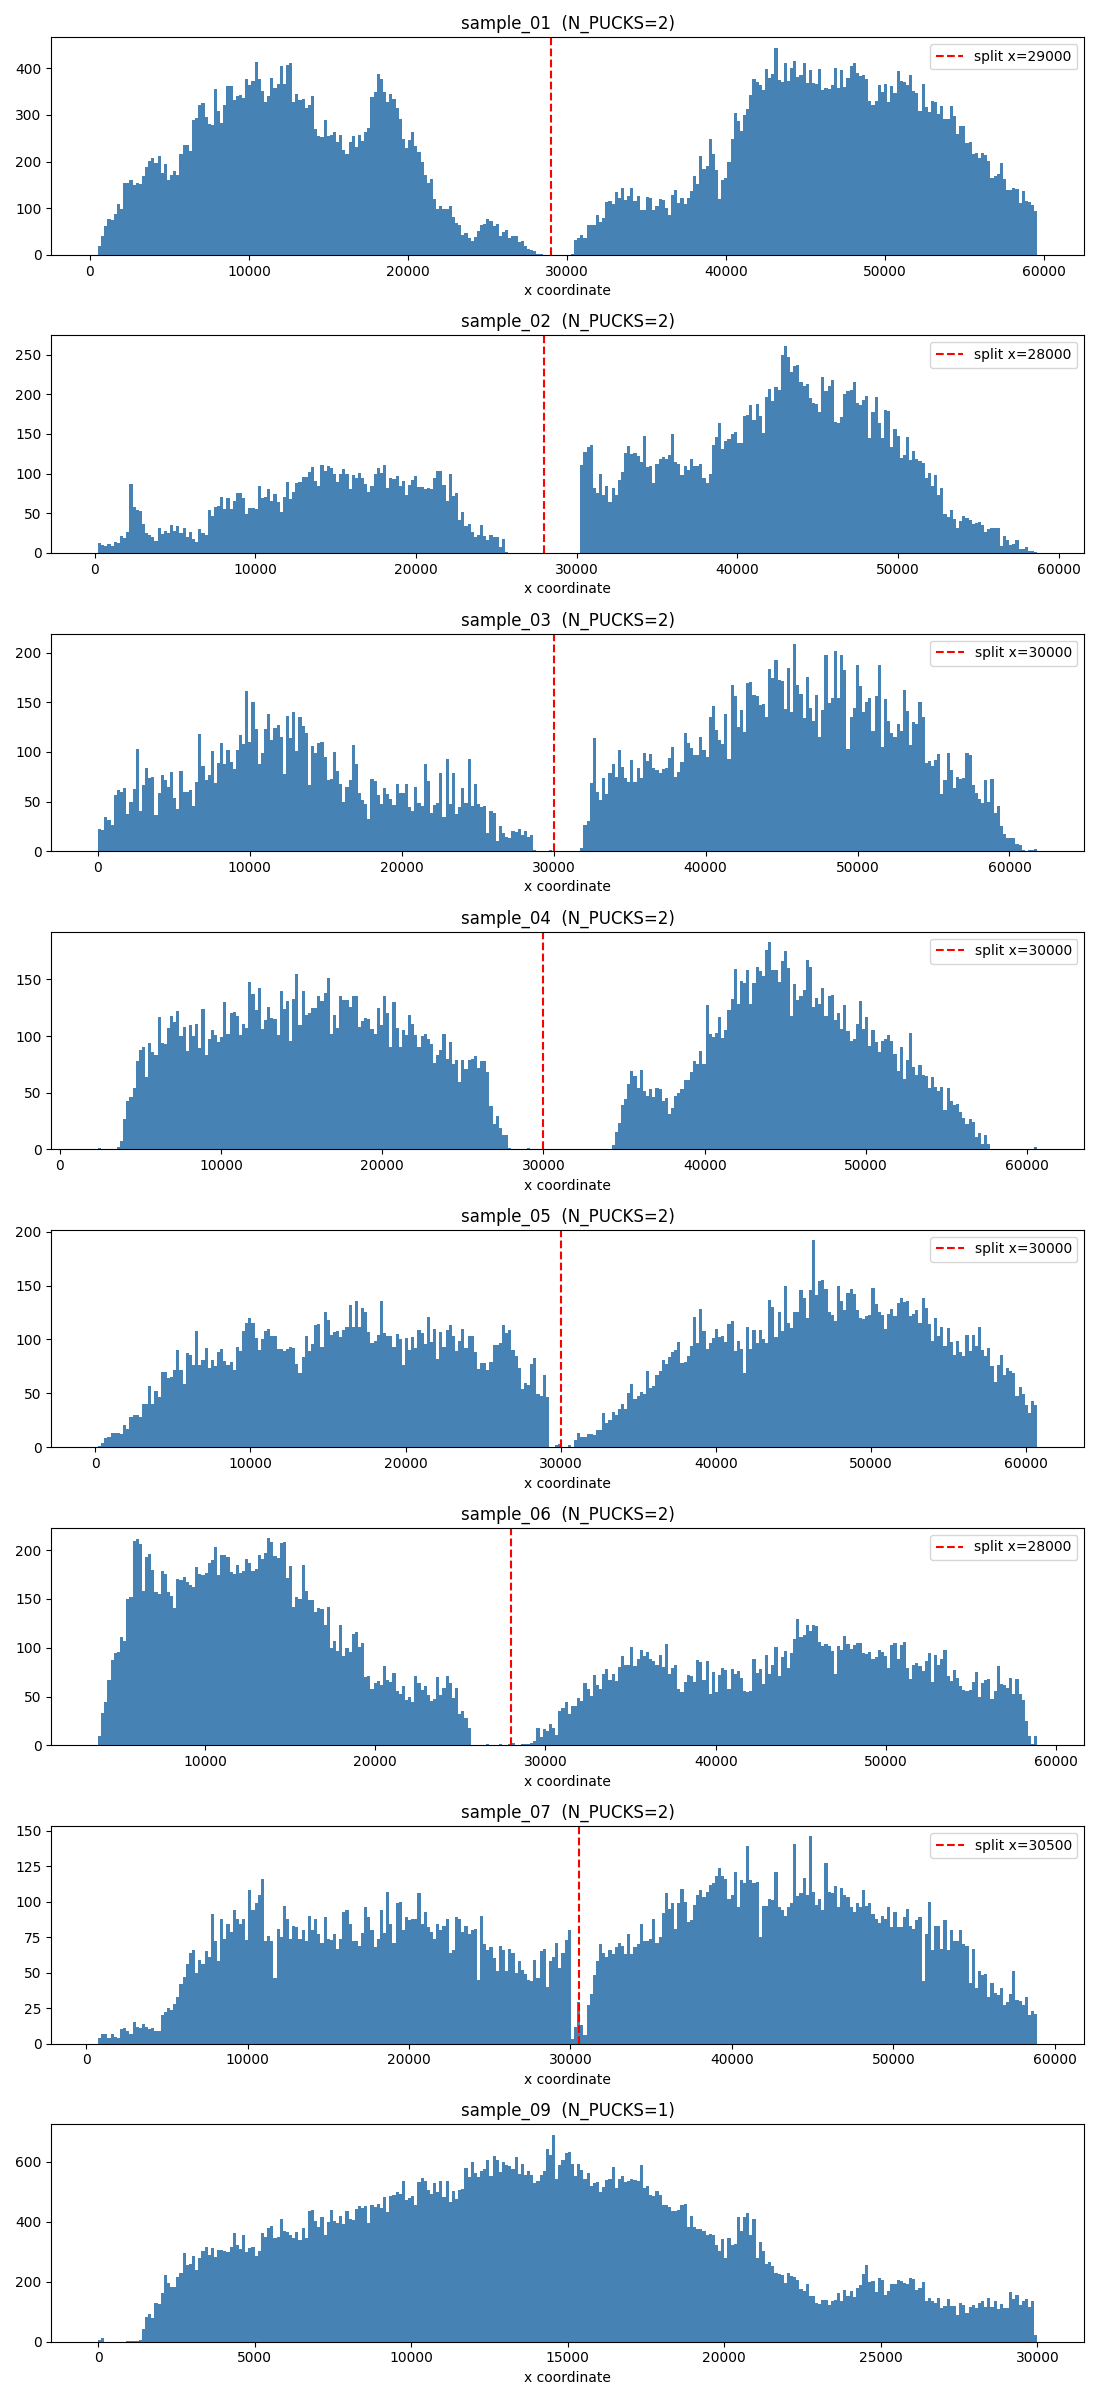

In [6]:
n = len(spatial_samples)
fig, axes = plt.subplots(n, 1, figsize=(11, 3 * n), squeeze=False)

for ax, sample in zip(axes[:, 0], spatial_samples):
    mask = (adata.obs[SAMPLE_COL] == sample) & adata.obs["has_spatial"]
    x = adata.obsm["spatial"][mask.values, 0]
    ax.hist(x, bins=300, color="steelblue")
    n_pucks = N_PUCKS.get(sample, "?")
    ax.set_title(f"{sample}  (N_PUCKS={n_pucks})")
    ax.set_xlabel("x coordinate")
    for sx in sorted(SPLIT_X.get(sample, [])):
        ax.axvline(sx, color="red", lw=1.5, linestyle="--", label=f"split x={sx:.0f}")
    if SPLIT_X.get(sample):
        ax.legend()

plt.tight_layout()


## Step 2 — Interactive alignment

Select sample + puck, adjust angle / flip, then click **Save transform**.
Repeat for every (sample, puck) combination.
The puck dropdown updates automatically based on `N_PUCKS`.

In [7]:
# Helper functions -------------------------------------------------------------
# One canonical set of coordinate-transform primitives used by ALL steps below:
# Step-2 widget, Step-2b export, Step-3 line-drawing widget, and the apply step.
# They must all call transform_puck identically so that everything maps onto the
# same coordinate space.

def _puck_labels(sample):
    """Return ['puck1', 'puck2', ...] for `sample`."""
    return [f"puck{i+1}" for i in range(N_PUCKS.get(sample, 0))]


def _rot_flip(coords, angle, flip_x, flip_y):
    """Rotate `coords` by `angle` degrees around (0, 0), then flip axes."""
    c = coords.copy()
    a = np.radians(angle)
    R = np.array([[np.cos(a), -np.sin(a)],
                  [np.sin(a),  np.cos(a)]])
    c = c @ R.T
    if flip_x: c[:, 0] = -c[:, 0]
    if flip_y: c[:, 1] = -c[:, 1]
    return c


def transform_puck(coords, t, ref_coords=None):
    """
    Apply rotation+flip to `coords`, then shift so that min(ref) goes to (0, 0).

    Parameters
    ----------
    coords    : (N, 2) array to transform.
    t         : dict with keys 'angle', 'flip_x', 'flip_y'.
    ref_coords: (M, 2) reference used to compute the global origin.
                Pass ALL cells in the puck so that every cell-type subset
                shares the same coordinate origin.  Defaults to `coords`.
    """
    if ref_coords is None:
        ref_coords = coords
    offset = _rot_flip(ref_coords, t["angle"], t["flip_x"], t["flip_y"]).min(axis=0)
    return _rot_flip(coords, t["angle"], t["flip_x"], t["flip_y"]) - offset


def get_puck_raw_coords(sample, puck_label, cell_types=None):
    """
    Return (N, 2) *raw* spatial coordinates for one puck of a sample.

    Uses obsm['spatial_raw'] if it exists (after the apply step has run),
    otherwise falls back to obsm['spatial'] (the original values).
    Splits are applied on the first coordinate axis using SPLIT_X.
    """
    spatial_key = "spatial_raw" if "spatial_raw" in adata.obsm else "spatial"

    mask = (adata.obs[SAMPLE_COL] == sample) & adata.obs["has_spatial"]
    if cell_types is not None:
        mask &= adata.obs["ct_for_deg"].isin(cell_types)

    coords = adata.obsm[spatial_key][mask.values]

    n = N_PUCKS.get(sample, 0)
    if n <= 1:
        return coords

    puck_idx = int(puck_label.replace("puck", "")) - 1
    splits   = sorted(SPLIT_X.get(sample, []))
    lo = splits[puck_idx - 1] if puck_idx > 0     else -np.inf
    hi = splits[puck_idx]     if puck_idx < n - 1 else  np.inf
    return coords[(coords[:, 0] >= lo) & (coords[:, 0] < hi)]


def _puck_data(sample, puck, cell_types=None):
    """Return (coords_2d, obs_df) after the Step-2 individual transform.
    Same routine used everywhere below -- the export step, the apply step, etc."""
    spatial_key = "spatial_raw" if "spatial_raw" in adata.obsm else "spatial"

    s_mask     = (adata.obs[SAMPLE_COL] == sample) & adata.obs["has_spatial"]
    all_coords = adata.obsm[spatial_key][s_mask.values]
    all_obs    = adata.obs[s_mask]

    n = N_PUCKS.get(sample, 0)
    if n > 1:
        puck_idx = int(puck.replace("puck", "")) - 1
        splits   = sorted(SPLIT_X.get(sample, []))
        lo = splits[puck_idx - 1] if puck_idx > 0     else -np.inf
        hi = splits[puck_idx]     if puck_idx < n - 1 else  np.inf
        pm = (all_coords[:, 0] >= lo) & (all_coords[:, 0] < hi)
    else:
        pm = np.ones(len(all_coords), dtype=bool)

    puck_coords = all_coords[pm]
    puck_obs    = all_obs.iloc[pm]

    if cell_types is not None:
        ct_mask     = puck_obs["ct_for_deg"].isin(cell_types).values
        puck_coords = puck_coords[ct_mask]
        puck_obs    = puck_obs.iloc[ct_mask]

    key = (sample, puck)
    if key in transforms and len(puck_coords) > 0:
        ref = get_puck_raw_coords(sample, puck)
        puck_coords = transform_puck(puck_coords, transforms[key], ref_coords=ref)

    return puck_coords, puck_obs


def _sample_offset(sample):
    """Shared centroid across ALL pucks of `sample` (post Step-2 transform) --
    used as a common origin for EVERY puck's CloudCompare export/reimport, so
    that pucks' relative positions as shown in CloudCompare match their
    relative positions in the raw adata coordinates.

    Centering each puck on its OWN centroid instead (an earlier version of this
    notebook did this) silently reintroduces a residual translation error equal
    to the difference between the pucks' own centroids: two independently
    self-centered pucks appear to already overlap near (0, 0) in CloudCompare
    even when their true (raw) positions don't, so "visually aligning" them
    there does not correspond to actual overlap in raw space. Using one shared
    offset for every puck of a sample avoids this entirely -- it just shifts
    the whole sample by a constant, which cancels out exactly in
    `_apply_cc_matrix`'s correction regardless of the offset's size."""
    coords = np.concatenate(
        [_puck_data(sample, p)[0] for p in _puck_labels(sample)], axis=0
    )
    return coords.mean(axis=0)


def side_of_line(coords, p1, p2):
    """
    Signed area of triangle (p1, p2, point) for each row of `coords`.
    Positive means the point is to the LEFT of the directed vector p1->p2 (healthy side).
    """
    return (
        (p2[0] - p1[0]) * (coords[:, 1] - p1[1])
      - (p2[1] - p1[1]) * (coords[:, 0] - p1[0])
    )


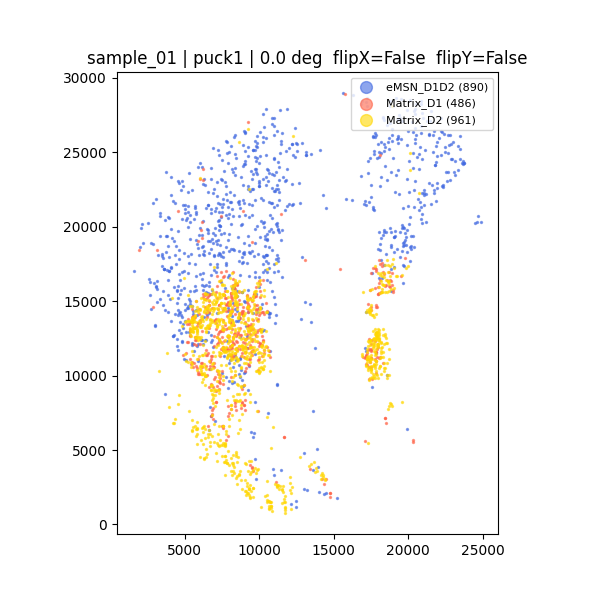

In [8]:
CT_ALIGN_COLOR = {
    "eMSN_D1D2": "royalblue",
    "Matrix_D1":  "tomato",
    "Matrix_D2":  "gold",
}
CT_ALIGN = list(CT_ALIGN_COLOR.keys())

_s0     = spatial_samples[0]
_pucks0 = _puck_labels(_s0) or ["puck1"]

sample_dd  = widgets.Dropdown(options=spatial_samples, description="Sample:")
puck_dd    = widgets.Dropdown(options=_pucks0,          description="Puck:")
angle_sl   = widgets.FloatSlider(
    value=0, min=-180, max=180, step=0.5, description="Angle",
    continuous_update=True, layout=widgets.Layout(width="500px"))
flip_x_cb  = widgets.Checkbox(value=False, description="Flip X")
flip_y_cb  = widgets.Checkbox(value=False, description="Flip Y")
save_btn   = widgets.Button(description="Save transform", button_style="success")
status_lbl = widgets.Label(value="")

fig_align, ax_align = plt.subplots(figsize=(6, 6))
ax_align.set_aspect("equal")

def _current_t():
    return dict(angle=angle_sl.value, flip_x=flip_x_cb.value, flip_y=flip_y_cb.value)

def _update_plot(_=None):
    sample, puck = sample_dd.value, puck_dd.value
    n = N_PUCKS.get(sample, 0)
    if n == 0:
        status_lbl.value = f"{sample}: N_PUCKS=0 -- nothing to show"
        return
    splits = SPLIT_X.get(sample, [])
    if n > 1 and len(splits) < n - 1:
        status_lbl.value = f"{sample}: fill in SPLIT_X first ({n-1} value(s) needed)"
        return

    t = _current_t()

    ref_coords = get_puck_raw_coords(sample, puck)
    if len(ref_coords) == 0:
        status_lbl.value = f"{sample}/{puck}: 0 cells found"
        ax_align.cla(); fig_align.canvas.draw_idle()
        return

    ax_align.cla()
    ax_align.set_aspect("equal")
    counts = {}
    for ct, color in CT_ALIGN_COLOR.items():
        raw = get_puck_raw_coords(sample, puck, cell_types=[ct])
        counts[ct] = len(raw)
        if len(raw) == 0:
            continue
        c = transform_puck(raw, t, ref_coords=ref_coords)
        ax_align.scatter(c[:, 0], c[:, 1], s=2, alpha=0.6,
                         color=color, label=f"{ct} ({len(raw)})", rasterized=True)

    status_lbl.value = "  |  ".join(f"{ct}: {n}" for ct, n in counts.items())
    ax_align.legend(markerscale=6, loc="upper right", fontsize=8)
    ax_align.set_title(
        f"{sample} | {puck} | {t['angle']:.1f} deg  flipX={t['flip_x']}  flipY={t['flip_y']}")
    fig_align.canvas.draw_idle()

def _on_sample_change(_):
    pucks = _puck_labels(sample_dd.value)
    puck_dd.options = pucks if pucks else ["puck1"]
    _on_puck_change(None)

def _on_puck_change(_):
    key = (sample_dd.value, puck_dd.value)
    if key in transforms:
        t = transforms[key]
        angle_sl.value  = t["angle"]
        flip_x_cb.value = t["flip_x"]
        flip_y_cb.value = t["flip_y"]
    else:
        angle_sl.value = 0; flip_x_cb.value = False; flip_y_cb.value = False
    _update_plot()

def _save(_):
    key = (sample_dd.value, puck_dd.value)
    transforms[key] = _current_t()
    status_lbl.value = f"Saved transform for {key}"

sample_dd.observe(_on_sample_change, names="value")
puck_dd.observe(_on_puck_change,     names="value")
for w in [angle_sl, flip_x_cb, flip_y_cb]:
    w.observe(_update_plot, names="value")
save_btn.on_click(_save)

display(widgets.VBox([
    widgets.HBox([sample_dd, puck_dd]),
    angle_sl,
    widgets.HBox([flip_x_cb, flip_y_cb, save_btn]),
    status_lbl,
]))
_on_puck_change(None)


## Step 2b — Inter-puck alignment via CloudCompare (matrix-based, NEW)

steps:
- save csv
- doenalod locally on VM
- open cloudcomapre
- drag and drop csv to load cvs of same sample
- attention we upload:
    - do NOT allow to shoft/scale corodinate
    - paya ttentio that each col is the cirrepct type
        - ex zone color = "scalar"
- use rotate/trnalste tool to move clouds
    - attention rigth click to shift
    - roate onyl aournd z
- export matrix: bottom right fo thter
    - scorll daonw
    - download ASCII

### 2b.1 — Export a small landmark-only reference cloud per puck

For every multi-puck sample, exports **only the `Matrix_D1` cells** (post
Step-2 transform) per puck, as `<sample>__<puck>_landmark.csv` — columns
`x, y, label`. `label` is a globally-consistent integer encoding of `zone`
(same code = same zone in every file), meant to be loaded as a CloudCompare
scalar field for colorizing.

This cloud is a **pure visual aid** for dragging in CloudCompare — small
enough that there's no rendering/occlusion problem, and nothing from it is
ever read back into the notebook. What actually gets applied to `adata` is
the **transformation matrix** you copy out of CloudCompare after aligning it
(Step 2b.2) — that matrix gets applied directly to every cell of the puck
straight from `adata`, not to this CSV's coordinates.

**Coordinates are centered on a shared per-sample offset before export**
(`_sample_offset` — the combined centroid of *all* pucks in the sample, not
each puck's own centroid; see that function's docstring for why using a
per-puck offset instead is a subtle bug that silently misaligns pucks by the
difference between their centroids). Our raw coordinates are tens of
thousands of units from the origin, and CloudCompare's own "Global Shift" —
which it silently applies to large coordinates for float precision —
computes its Transformation History matrix in that *shifted* local frame, not
the original global one (this is a known CloudCompare limitation; a fix
landed only in 2.13-alpha). Centering ourselves keeps the exported
coordinates small enough that CloudCompare's own shift is unlikely to trigger
at all, and Step 2b.2 corrects for our own (known, reproducible) centering
exactly. **Still decline any "shift coordinates?" prompt CloudCompare shows
on import** — we can only correct for the offset we chose ourselves, not an
additional one CloudCompare might add.

In [22]:
CC_DIR = Path("/home/gdallagl/myworkdir/XDP/data/_old/cloudcompare_puck_csv")
CC_DIR.mkdir(parents=True, exist_ok=True)

CT_BY_ZONE_CC = "Matrix_D1"

# Global, consistent zone -> integer code mapping (must NOT be computed per-subset,
# otherwise the same zone could get a different code in different exported files).
_ZONE_CATEGORIES = sorted(adata.obs["zone"].dropna().unique().tolist())
_ZONE_TO_CODE    = {z: i for i, z in enumerate(_ZONE_CATEGORIES)}

multi_puck_samples = [s for s in spatial_samples if N_PUCKS.get(s, 0) >= 2]

for sample in multi_puck_samples:
    offset = _sample_offset(sample)   # SAME offset for every puck of this sample
    for puck in _puck_labels(sample):
        coords, obs = _puck_data(sample, puck, [CT_BY_ZONE_CC])
        coords = coords - offset
        # .astype(object) first: obs["zone"] is a pandas Categorical, and .map() on
        # a Categorical returns another Categorical whose categories don't include
        # -1, so a later .fillna(-1) would raise ("set the categories first").
        label = obs["zone"].astype(object).map(_ZONE_TO_CODE).fillna(-1).astype(int).to_numpy()

        path = CC_DIR / f"{sample}__{puck}.csv"
        pd.DataFrame({
            "x":     coords[:, 0],
            "y":     coords[:, 1],
            "z":     np.zeros(len(coords), dtype=int),
            "label": label,
        }).to_csv(path, index=False)
        print(f"  wrote {path.name}  ({len(coords)} cells)")

print(f"\nzone -> label mapping: {_ZONE_TO_CODE}")
print(f"Open these CSVs in CloudCompare from: {CC_DIR}")


  wrote sample_01__puck1.csv  (486 cells)
  wrote sample_01__puck2.csv  (475 cells)
  wrote sample_02__puck1.csv  (945 cells)
  wrote sample_02__puck2.csv  (1432 cells)
  wrote sample_03__puck1.csv  (403 cells)
  wrote sample_03__puck2.csv  (1168 cells)
  wrote sample_04__puck1.csv  (696 cells)
  wrote sample_04__puck2.csv  (347 cells)
  wrote sample_05__puck1.csv  (897 cells)
  wrote sample_05__puck2.csv  (702 cells)
  wrote sample_06__puck1.csv  (271 cells)
  wrote sample_06__puck2.csv  (232 cells)
  wrote sample_07__puck1.csv  (539 cells)
  wrote sample_07__puck2.csv  (602 cells)

zone -> label mapping: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5}
Open these CSVs in CloudCompare from: /home/gdallagl/myworkdir/XDP/data/_old/cloudcompare_puck_csv


### 2b.2 — Read CloudCompare's transformation matrices and apply them

For every puck (in every multi-puck sample), read
`<sample>__<puck>_matrix.txt` (the 4x4 matrix you copied out of CloudCompare's
"Transformation history" / Console) and apply it **directly to that puck's
full cell set from `adata`** (all cell types, not just the landmark ones used
for the visual reference in Step 2b.1). Nothing is read back from CloudCompare
except this matrix — no coordinate CSV round-trip, so nothing can be dropped,
reordered, or occluded.

The matrix was computed by CloudCompare on our **centered** export (Step
2b.1), so applying it verbatim to `adata`'s un-centered coordinates would be
wrong -- the rotation is fine (rotation doesn't care about the origin), but
the translation needs correcting for the centering we chose:
`t_corrected = t + offset - R @ offset`, where `offset` is the same
**per-sample, shared-across-pucks** `_sample_offset(sample)` used at export
time (not a per-puck offset — see that function's docstring). This is exact
regardless of how large `offset` is, unlike leaving it to CloudCompare's own
internal Global Shift (see Step 2b.1's note).

Single-puck samples (`N_PUCKS == 1`) need no CloudCompare step at all -- there
is nothing to align against, so the Step-2 transform is already final for them
and they're filled in automatically below.

In [25]:
def _read_cc_matrix(path):
    """Parse a CloudCompare 4x4 transformation matrix text file: 4 rows, 4
    numbers per row, space- or tab-separated (np.loadtxt splits on either) --
    exactly the format CloudCompare's Properties > Transformation history /
    Console output uses."""
    M = np.loadtxt(path)
    if M.shape != (4, 4):
        raise ValueError(f"{path}: expected a 4x4 matrix, got shape {M.shape}")
    return M


def _apply_cc_matrix(coords, M, offset):
    """Apply a CloudCompare 4x4 rigid transform to 2D (x, y) coords, correcting
    for the centering applied before export (see Step 2b.1). Only the top-left
    2x2 block (rotation) and the top two entries of the last column
    (translation) are used -- any out-of-plane component is ignored."""
    R = M[:2, :2]
    t = M[:2, 3]
    t_corrected = t + offset - R @ offset
    return coords @ R.T + t_corrected


ALIGNED_COORDS_PATH = PARAMS_PATH.replace(".json", "_aligned_coords.csv")

if os.path.exists(ALIGNED_COORDS_PATH):
    _prev = pd.read_csv(ALIGNED_COORDS_PATH)
    aligned_coords = {row.barcode: (row.x, row.y) for row in _prev.itertuples()}
    print(f"Loaded {len(aligned_coords)} previously aligned cells from {ALIGNED_COORDS_PATH}")
else:
    aligned_coords = {}
    print("No previously saved aligned coordinates -- starting fresh")


for sample in spatial_samples:
    n = N_PUCKS.get(sample, 0)
    if n == 0:
        continue

    offset = _sample_offset(sample) if n > 1 else None   # SAME offset for every puck of this sample

    for puck in _puck_labels(sample):
        coords, obs = _puck_data(sample, puck)   # ALL cells in this puck, Step-2-transformed

        if n <= 1:
            # single-puck sample -- nothing to align against, Step-2 transform is final
            moved = coords
            note  = "(single puck, no CloudCompare step needed)"
        else:
            mpath = CC_DIR / f"{sample}__{puck}_matrix.txt"
            if not mpath.exists():
                print(f"  [SKIP] {sample}/{puck}: no {mpath.name} yet")
                continue
            M      = _read_cc_matrix(mpath)
            moved  = _apply_cc_matrix(coords, M, offset)
            note   = f"transformed via {mpath.name}"

        for barcode, xy in zip(obs.index.to_numpy(), moved):
            aligned_coords[barcode] = (xy[0], xy[1])
        print(f"  {sample}/{puck}: {len(obs)} cells  {note}")

print(f"\nTotal cells with a CloudCompare-sourced coordinate: {len(aligned_coords)}")


def _aligned_puck_data(sample, puck, cell_types=None):
    """(coords, obs) for the subset of `puck` that already has an aligned coordinate
    in `aligned_coords`. Used by Step 3 and Step 4 -- there is no transform here,
    just a lookup of the matrix-applied result computed above."""
    _, obs = _puck_data(sample, puck, cell_types)
    obs_names = obs.index.to_numpy()
    have = np.array([o in aligned_coords for o in obs_names])
    obs    = obs.iloc[have]
    obs_names = obs_names[have]
    coords = np.array([aligned_coords[o] for o in obs_names]) if len(obs_names) else np.empty((0, 2))
    return coords, obs


Loaded 125014 previously aligned cells from /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/puck_alignment_params_aligned_coords.csv
  sample_01/puck1: 29919 cells  transformed via sample_01__puck1_matrix.txt
  sample_01/puck2: 36431 cells  transformed via sample_01__puck2_matrix.txt
  sample_02/puck1: 7975 cells  transformed via sample_02__puck1_matrix.txt
  sample_02/puck2: 17939 cells  transformed via sample_02__puck2_matrix.txt
  sample_03/puck1: 9654 cells  transformed via sample_03__puck1_matrix.txt
  sample_03/puck2: 15474 cells  transformed via sample_03__puck2_matrix.txt
  sample_04/puck1: 12415 cells  transformed via sample_04__puck1_matrix.txt
  sample_04/puck2: 10793 cells  transformed via sample_04__puck2_matrix.txt
  sample_05/puck1: 12097 cells  transformed via sample_05__puck1_matrix.txt
  sample_05/puck2: 13854 cells  transformed via sample_05__puck2_matrix.txt
  sample_06/puck1: 15109 cells  transformed via sample_06__puck1_matrix.txt
  sample_06/puck2: 11939 

### 2b.3 — QC: overlay all pucks of a sample using the matrix-transformed coordinates

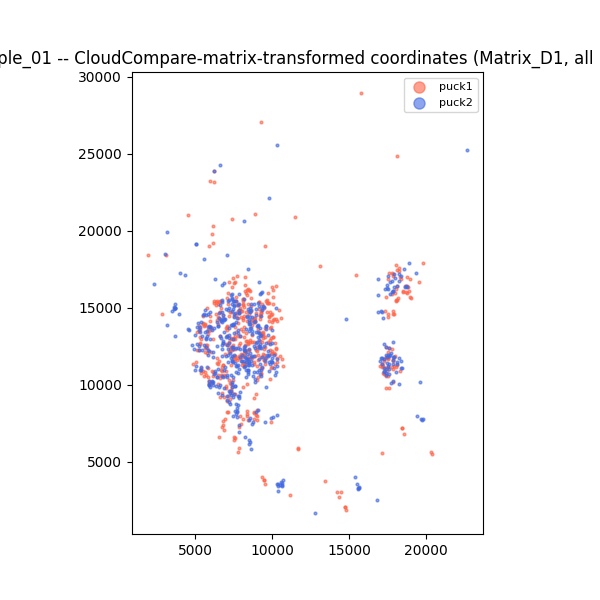

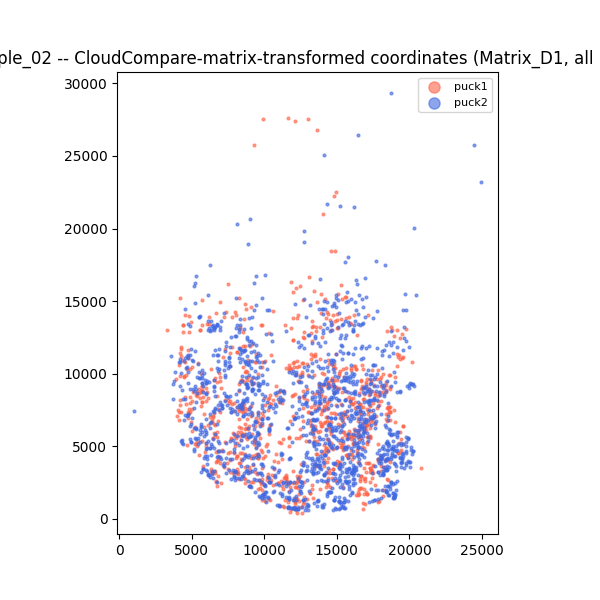

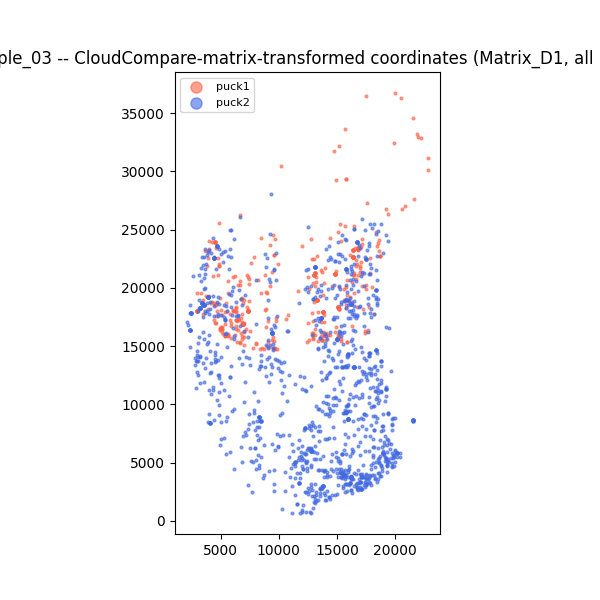

In [26]:
_QC_COLORS = ["tomato", "royalblue", "gold", "mediumseagreen"]

for sample in multi_puck_samples[:3]:
    fig, ax = plt.subplots(figsize=(6, 6)); ax.set_aspect("equal")
    for i, puck in enumerate(_puck_labels(sample)):
        c, _ = _aligned_puck_data(sample, puck, ["Matrix_D1"])
        if len(c):
            ax.scatter(c[:, 0], c[:, 1], s=4, alpha=0.6,
                      color=_QC_COLORS[i % len(_QC_COLORS)], label=puck)
    ax.legend(markerscale=4, fontsize=8)
    ax.set_title(f"{sample} -- CloudCompare-matrix-transformed coordinates (Matrix_D1, all pucks)")
    plt.show()


In [ ]:
pd.DataFrame(
    [(k, v[0], v[1]) for k, v in aligned_coords.items()],
    columns=["barcode", "x", "y"],
).to_csv(ALIGNED_COORDS_PATH, index=False)
print(f"Saved {len(aligned_coords)} aligned coordinates -> {ALIGNED_COORDS_PATH}")


## Step 3 — Draw dead / healthy boundary

Select sample + puck, then **click exactly 2 points** on the scatter plot to define
the dividing line between dead and healthy tissue.

**Convention:** cells to the **LEFT** of the directed vector p1 -> p2 are labelled `healthy`;
cells to the **RIGHT** are labelled `dead`.
Click Reset to redo. Previously saved lines are reloaded automatically.

> The plot uses the matrix-transformed coordinates from Step 2b (no further
> transform is applied), so the line you draw maps exactly onto the region
> labels written to `adata` in Step 4.

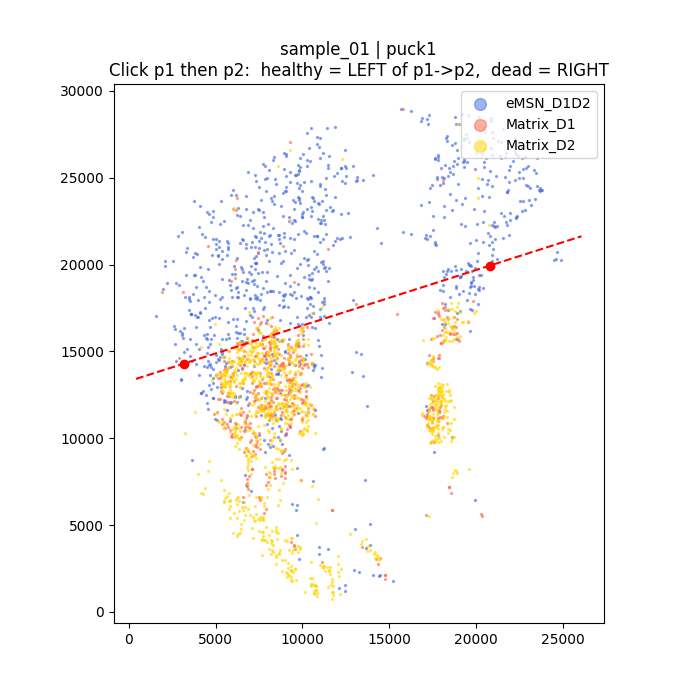

In [27]:
CT_LINE_COLOR = {
    "eMSN_D1D2": "royalblue",
    "Matrix_D1":  "tomato",
    "Matrix_D2":  "gold",
}

_s0b     = spatial_samples[0]
_pucks0b = _puck_labels(_s0b) or ["puck1"]
_click_buf = []

sample_dd2  = widgets.Dropdown(options=spatial_samples, description="Sample:")
puck_dd2    = widgets.Dropdown(options=_pucks0b,         description="Puck:")
reset_btn   = widgets.Button(description="Reset line", button_style="warning")
line_status = widgets.Label(value="")

fig_line, ax_line = plt.subplots(figsize=(7, 7))
ax_line.set_aspect("equal")

def _draw_puck_for_line(_=None):
    sample, puck = sample_dd2.value, puck_dd2.value
    key = (sample, puck)

    ax_line.cla()
    ax_line.set_aspect("equal")
    _click_buf.clear()

    n = N_PUCKS.get(sample, 0)
    if n == 0:
        line_status.value = f"{sample}: N_PUCKS=0 -- skipping"
        fig_line.canvas.draw_idle(); return

    splits = SPLIT_X.get(sample, [])
    if n > 1 and len(splits) < n - 1:
        line_status.value = f"{sample}: fill in SPLIT_X first"
        fig_line.canvas.draw_idle(); return

    any_pts = False
    for ct, color in CT_LINE_COLOR.items():
        c, _ = _aligned_puck_data(sample, puck, [ct])
        if len(c) == 0:
            continue
        any_pts = True
        ax_line.scatter(c[:, 0], c[:, 1], s=2, alpha=0.5,
                        color=color, label=ct, rasterized=True)

    if not any_pts:
        line_status.value = f"No aligned coordinates for {key} yet -- do Step 2b first"
        fig_line.canvas.draw_idle(); return

    ax_line.legend(markerscale=6, loc="upper right")
    ax_line.set_title(
        f"{sample} | {puck}\n"
        "Click p1 then p2:  healthy = LEFT of p1->p2,  dead = RIGHT")

    if key in line_points:
        (x1, y1), (x2, y2) = line_points[key]
        xs = np.array(ax_line.get_xlim())
        slope = (y2 - y1) / (x2 - x1 + 1e-12)
        ax_line.plot(xs, y1 + slope * (xs - x1), "r--", lw=1.5, zorder=4)
        ax_line.plot([x1, x2], [y1, y2], "ro", ms=6, zorder=5)
        line_status.value = f"Existing line for {key} -- click Reset to redo"
    else:
        line_status.value = "Click 2 points: healthy is to the LEFT of p1->p2"

    fig_line.canvas.draw_idle()

def _on_line_click(event):
    if event.inaxes != ax_line or event.button != 1:
        return
    _click_buf.append((event.xdata, event.ydata))
    ax_line.plot(event.xdata, event.ydata, "ro", ms=6, zorder=5)
    fig_line.canvas.draw_idle()

    if len(_click_buf) == 2:
        (x1, y1), (x2, y2) = _click_buf
        xs = np.array(ax_line.get_xlim())
        slope = (y2 - y1) / (x2 - x1 + 1e-12)
        ax_line.plot(xs, y1 + slope * (xs - x1), "r--", lw=1.5, zorder=4)
        key = (sample_dd2.value, puck_dd2.value)
        line_points[key] = [(x1, y1), (x2, y2)]
        line_status.value = f"Saved line for {key}"
        _click_buf.clear()
        fig_line.canvas.draw_idle()

def _reset_line(_):
    line_points.pop((sample_dd2.value, puck_dd2.value), None)
    _draw_puck_for_line()

def _on_sample2_change(_):
    pucks = _puck_labels(sample_dd2.value)
    puck_dd2.options = pucks if pucks else ["puck1"]
    _draw_puck_for_line()

sample_dd2.observe(_on_sample2_change,              names="value")
puck_dd2.observe(lambda _: _draw_puck_for_line(),   names="value")
reset_btn.on_click(_reset_line)
fig_line.canvas.mpl_connect("button_press_event", _on_line_click)

display(widgets.VBox([
    widgets.HBox([sample_dd2, puck_dd2, reset_btn]),
    line_status,
]))
_draw_puck_for_line()


## Step 4 — Apply everything and write back to adata

No `transform_puck` / rotation math happens here anymore. For every puck, this
looks up each cell's matrix-transformed `(x, y)` from `aligned_coords` (built
in Step 2b, matched by barcode) and writes it straight into
`obsm['spatial_aligned']`, then labels dead/healthy region using the Step-3
boundary line in that same coordinate space.

In [37]:
# Guard against re-running: only snapshot raw coords once.
if "spatial_raw" not in adata.obsm:
    adata.obsm["spatial_raw"] = adata.obsm["spatial"].copy()
    print("Saved originals to obsm['spatial_raw']")

adata.obsm["spatial_aligned"] = np.full((adata.n_obs, 2), np.nan)
adata.obs["puck"]   = pd.NA
adata.obs["region"] = pd.NA

for sample in spatial_samples:
    n = N_PUCKS.get(sample, 0)
    if n == 0:
        print(f"[SKIP] {sample}: N_PUCKS=0")
        continue

    for puck in _puck_labels(sample):
        _, obs = _puck_data(sample, puck)
        obs_names = obs.index.to_numpy()
        have      = np.array([o in aligned_coords for o in obs_names])
        n_total, n_have = len(obs_names), int(have.sum())

        if n_have == 0:
            print(f"  [SKIP] {sample}/{puck}: no aligned coordinates yet -- do Step 2b")
            continue
        if n_have < n_total:
            print(f"  [WARN] {sample}/{puck}: only {n_have}/{n_total} cells aligned")

        matched_obs = obs_names[have]
        coords      = np.array([aligned_coords[o] for o in matched_obs])
        safe_idx    = adata.obs_names.get_indexer(matched_obs)

        adata.obs.loc[matched_obs, "puck"] = puck
        adata.obsm["spatial_aligned"][safe_idx] = coords

        key = (sample, puck)
        if key in line_points:
            p1, p2 = line_points[key]
            labels = np.where(side_of_line(coords, p1, p2) > 0, "dead", "healthy")
            adata.obs.loc[matched_obs, "region"] = labels
            n_h = (labels == "healthy").sum()
            n_d = (labels == "dead").sum()
            region_info = f"healthy={n_h}, dead={n_d}"
        else:
            region_info = "region=NA (no boundary line drawn)"

        print(f"  {sample}/{puck}: {n_have} cells  |  {region_info}")

adata.obsm["spatial"]   = adata.obsm["spatial_aligned"]
adata.obsm["X_spatial"] = adata.obsm["spatial_aligned"]

print("\nSummary:")
display(
    adata.obs
    .groupby([SAMPLE_COL, "puck", "region"], dropna=False, observed=True)
    .size()
    .to_frame("n_cells")
)


adata.obs["image"] = adata.obs["sample"].astype(str) + "_" + adata.obs["puck"].astype(str)

  sample_01/puck1: 29919 cells  |  healthy=15500, dead=14419
  sample_01/puck2: 36431 cells  |  healthy=16126, dead=20305
  sample_02/puck1: 7975 cells  |  healthy=5525, dead=2450
  sample_02/puck2: 17939 cells  |  healthy=10722, dead=7217
  sample_03/puck1: 9654 cells  |  healthy=4634, dead=5020
  sample_03/puck2: 15474 cells  |  healthy=13823, dead=1651
  sample_04/puck1: 12415 cells  |  healthy=12415, dead=0
  sample_04/puck2: 10793 cells  |  healthy=6805, dead=3988
  sample_05/puck1: 12097 cells  |  healthy=12097, dead=0
  sample_05/puck2: 13854 cells  |  healthy=13501, dead=353
  sample_06/puck1: 15109 cells  |  healthy=8941, dead=6168
  sample_06/puck2: 11939 cells  |  healthy=6613, dead=5326
  sample_07/puck1: 9752 cells  |  healthy=9752, dead=0
  sample_07/puck2: 11983 cells  |  healthy=11982, dead=1
  sample_09/puck1: 99886 cells  |  healthy=92332, dead=7554

Summary:


n_cells
sample    puck  region          
sample_01 puck1 dead       14419
                healthy    15500
          puck2 dead       20305
                healthy    16126
          NaN   NaN        29059
sample_02 puck1 dead        2450
                healthy     5525
          puck2 dead        7217
                healthy    10722
          NaN   NaN        15938
sample_03 puck1 dead        5020
                healthy     4634
          puck2 dead        1651
                healthy    13823
          NaN   NaN        14520
sample_04 puck1 healthy    12415
          puck2 dead        3988
                healthy     6805
          NaN   NaN        12170
sample_05 puck1 healthy    12097
          puck2 dead         353
                healthy    13501
          NaN   NaN         8475
sample_06 puck1 dead        6168
                healthy     8941
          puck2 dead        5326
                healthy     6613
          NaN   NaN         9822
sample_07 puck1 healthy     9752
          puck2 dead           1
                healthy    11982
          NaN   NaN         5493
sample_08 NaN   NaN        95059
sample_09 puck1 dead        7554
                healthy    92332
          NaN   NaN        31902

In [29]:
# Quick sanity check: raw vs aligned should differ (transform was applied)
diff = np.abs(adata.obsm["spatial_raw"] - adata.obsm["spatial_aligned"])
print(f"Mean |raw - aligned|: {np.nanmean(diff):.1f}  (0 would mean transform was not applied)")

_check_sample, _check_puck = spatial_samples[0], "puck1"
_mask = (adata.obs["sample"] == _check_sample) & (adata.obs["puck"] == _check_puck)
print(f"\n{_check_sample} / {_check_puck}  ({_mask.sum()} cells)")
print("  raw (first 3):    ", adata.obsm["spatial_raw"][_mask.values][:3].round(1).tolist())
print("  aligned (first 3):", adata.obsm["spatial_aligned"][_mask.values][:3].round(1).tolist())


Mean |raw - aligned|: 13642.3  (0 would mean transform was not applied)

sample_01 / puck1  (29919 cells)
  raw (first 3):     [[21225.2, 4193.3], [16429.0, 3852.1], [14118.4, -4852.3]]
  aligned (first 3): [[20716.7, 18791.1], [15920.5, 18449.9], [13609.9, 9745.5]]


# Mark cells around hig_mito and atch

for high_mato_patch cells and patch_in_death and patch_in_healthy (indpelty D1D2), BIULD A RADIAL DISTNCE OF 100micors and matk all cells isnide with those names

the cells used as refence receive the tuccrent high_mito_althc or PAtch__ind_dea pathc_in _ehalthy names, while all otehr cells have none

In [31]:
from scipy.spatial import cKDTree

RADIUS_UM = 200  # radial distance threshold in microns

# create one new obs column per group, all set to None (will be filled below)
col_names = {
    "radial_high_mito_patch":  {"ct": ["-Mito_cluster_patch"], "region": "dead"},   # no region filter
    "radial_patch_in_death":   {"ct": ["Patch_D1", "Patch_D2"], "region": "dead"},
    "radial_patch_in_healthy": {"ct": ["Patch_D1", "Patch_D2"], "region": "healthy"},
}

for col in col_names:
    adata.obs[col] = None

# aligned 2D coordinates in µm for every cell (NaN if no spatial data)
coords = adata.obsm["spatial_aligned"]

# iterate over each physical tissue section independently
for sample in spatial_samples:
    for puck in _puck_labels(sample):

        # boolean mask selecting all cells that belong to this sample+puck
        puck_mask = (
            (adata.obs["sample"] == sample) &
            (adata.obs["puck"] == puck)
        ).values

        # global indices (into adata) of cells in this puck
        puck_idx = np.where(puck_mask)[0]

        # coords of those cells
        puck_coords = coords[puck_idx]

        # some cells have no spatial position (NaN) — keep only valid ones
        valid        = ~np.isnan(puck_coords[:, 0])
        valid_idx    = puck_idx[valid]      # global indices of spatially-valid cells
        valid_coords = puck_coords[valid]   # their (x, y) coordinates

        if len(valid_idx) == 0:
            continue  # this puck has no spatial cells, nothing to do

        # define the seed/reference masks for each group, restricted to this puck
        # wchih c3ll belogs to this seef
        ref_groups = {}
        for col_name, cfg in col_names.items():
            mask = adata.obs["ct_for_deg"].isin(cfg["ct"])
            if cfg["region"] is not None:
                mask = mask & (adata.obs["region"] == cfg["region"])
            ref_groups[col_name] = mask.values[valid_idx]


        for col_name, ref_local_mask in ref_groups.items():

            # coordinates of seed cells for this group within this puck
            ref_coords = valid_coords[ref_local_mask]

            if len(ref_coords) == 0:
                continue  # no seed cells in this puck for this group

            # build a KD-tree on the seed cells for fast nearest-neighbour lookup
            tree = cKDTree(ref_coords)

            # for every spatially-valid cell in the puck, find distance to its nearest seed cell
            # dist is distnace of closest cell
            dist, _ = tree.query(valid_coords, k=1, workers=-1)

            # select cells whose nearest seed is within RADIUS_UM
            # (seed cells themselves are at distance 0, so they are always included)
            near_global_idx = valid_idx[dist <= RADIUS_UM]

            # write the column name as the label for all cells inside the radius
            adata.obs.loc[adata.obs_names[near_global_idx], col_name] = col_name

            n_ref   = ref_local_mask.sum()
            n_total = (adata.obs.loc[adata.obs_names[valid_idx], col_name].notna()).sum()
            print(f"{sample}/{puck} | {col_name}: {n_ref} ref → {n_total} marked")


# create one final single col
# ATTENTION priority: first match wins
priority = ["radial_high_mito_patch", "radial_patch_in_death", "radial_patch_in_healthy"]

adata.obs["mito_radial_neighborhood"] = None
for col in reversed(priority):  # reversed so highest priority overwrites last
    mask = adata.obs[col].notna()
    adata.obs.loc[mask, "mito_radial_neighborhood"] = col


sample_01/puck1 | radial_high_mito_patch: 6 ref → 50 marked
sample_01/puck1 | radial_patch_in_death: 180 ref → 1075 marked
sample_01/puck1 | radial_patch_in_healthy: 153 ref → 792 marked
sample_01/puck2 | radial_patch_in_death: 153 ref → 1002 marked
sample_01/puck2 | radial_patch_in_healthy: 193 ref → 1383 marked
sample_02/puck1 | radial_high_mito_patch: 100 ref → 225 marked
sample_02/puck1 | radial_patch_in_death: 203 ref → 428 marked
sample_02/puck1 | radial_patch_in_healthy: 497 ref → 988 marked
sample_02/puck2 | radial_high_mito_patch: 173 ref → 696 marked
sample_02/puck2 | radial_patch_in_death: 359 ref → 1271 marked
sample_02/puck2 | radial_patch_in_healthy: 623 ref → 2158 marked
sample_03/puck1 | radial_high_mito_patch: 153 ref → 397 marked
sample_03/puck1 | radial_patch_in_death: 200 ref → 466 marked
sample_03/puck1 | radial_patch_in_healthy: 303 ref → 1070 marked
sample_03/puck2 | radial_high_mito_patch: 48 ref → 228 marked
sample_03/puck2 | radial_patch_in_death: 68 ref → 243

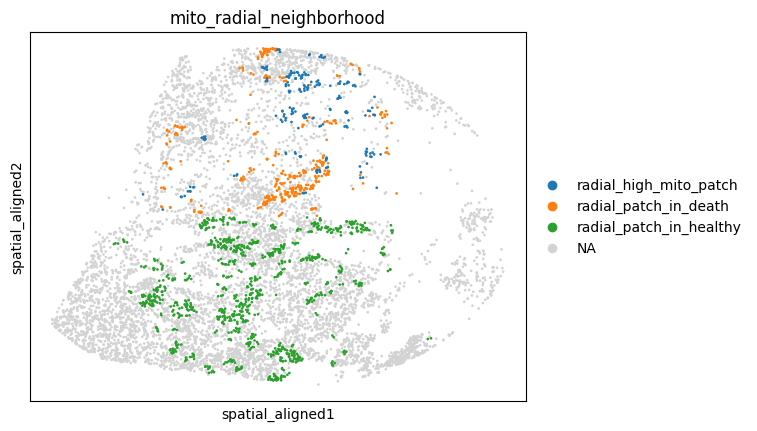

<Figure size 640x480 with 0 Axes>

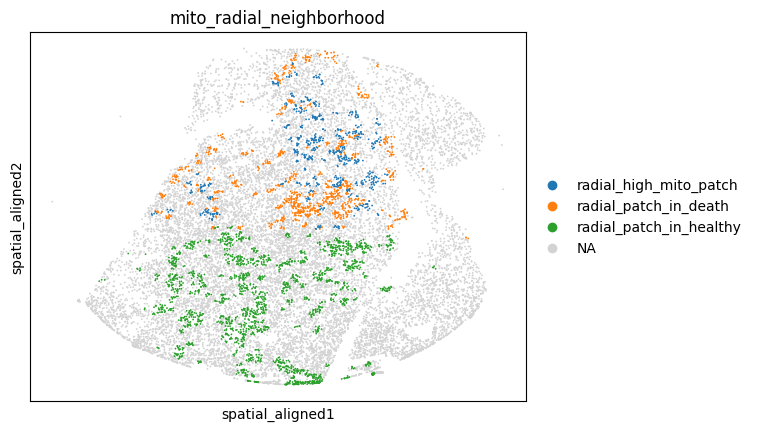

<Figure size 640x480 with 0 Axes>

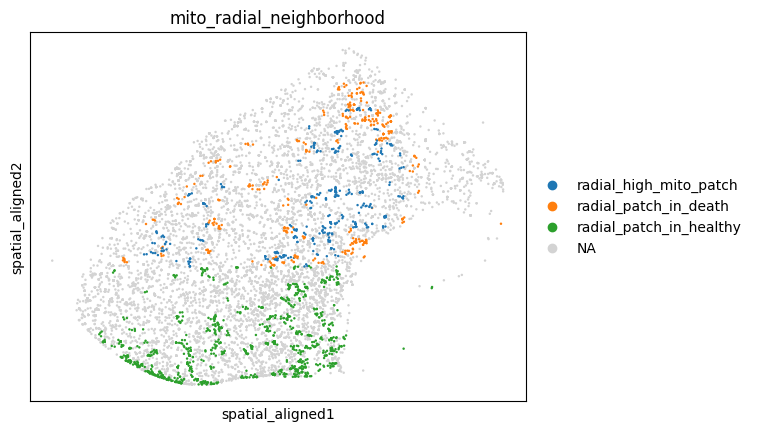

<Figure size 640x480 with 0 Axes>

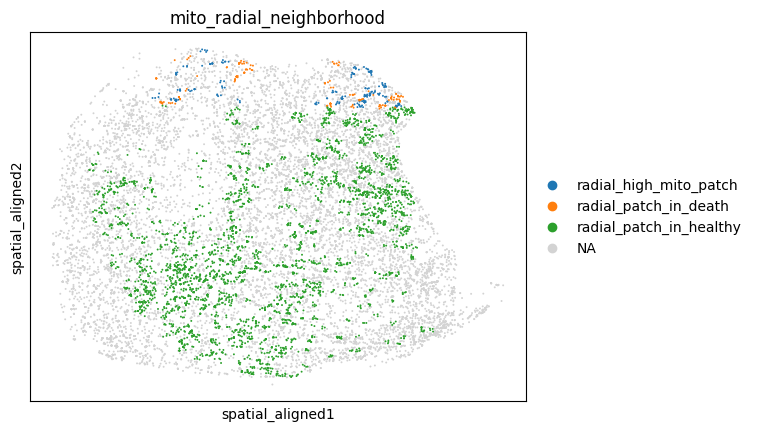

<Figure size 640x480 with 0 Axes>

In [34]:
SAMPLES_TO_PLOT = ["sample_02", "sample_03"]# "sample_09"]
%matplotlib inline


for sample in SAMPLES_TO_PLOT:
    for puck in _puck_labels(sample):
        sub = adata[
            (adata.obs["sample"] == sample) &
            (adata.obs["puck"] == puck) &
            adata.obs["puck"].notna()
        ].copy()

        if len(sub) == 0:
            continue

        sc.pl.embedding(sub, basis="spatial_aligned", color="mito_radial_neighborhood",)

        plt.tight_layout()
        plt.show()


## Step 5 — Save

`aligned_coords` was already saved to `ALIGNED_COORDS_PATH` in Step 2b.3 -- this just persists `N_PUCKS`/`SPLIT_X`/`transforms`/`line_points` (same as the original notebook).

In [44]:
with open(PARAMS_PATH, "w") as f:
    json.dump({
        "N_PUCKS": N_PUCKS,
        "SPLIT_X": SPLIT_X,
        "transforms": {
            f"{s}__{p}": v for (s, p), v in transforms.items()
        },
        "line_points": {
            f"{s}__{p}": [[pt[0], pt[1]] for pt in v]
            for (s, p), v in line_points.items()
        },
    }, f, indent=2)
print(f"Params saved -> {PARAMS_PATH}")


Params saved -> /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/puck_alignment_params.json


In [45]:
# Written under data/_old so this experimental pipeline never overwrites the
# original notebook's output (all_lib_adata_zoned_ct-cured_aligned.h5ad).
OUT_PATH = "/home/gdallagl/myworkdir/XDP/data/_old/all_lib_adata_zoned_ct-cured_aligned_cloudcompare.h5ad"
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
adata.write(OUT_PATH)
print(f"Saved -> {OUT_PATH}")


Saved -> /home/gdallagl/myworkdir/XDP/data/_old/all_lib_adata_zoned_ct-cured_aligned_cloudcompare.h5ad


# Test

In [36]:
adata

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_c

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of

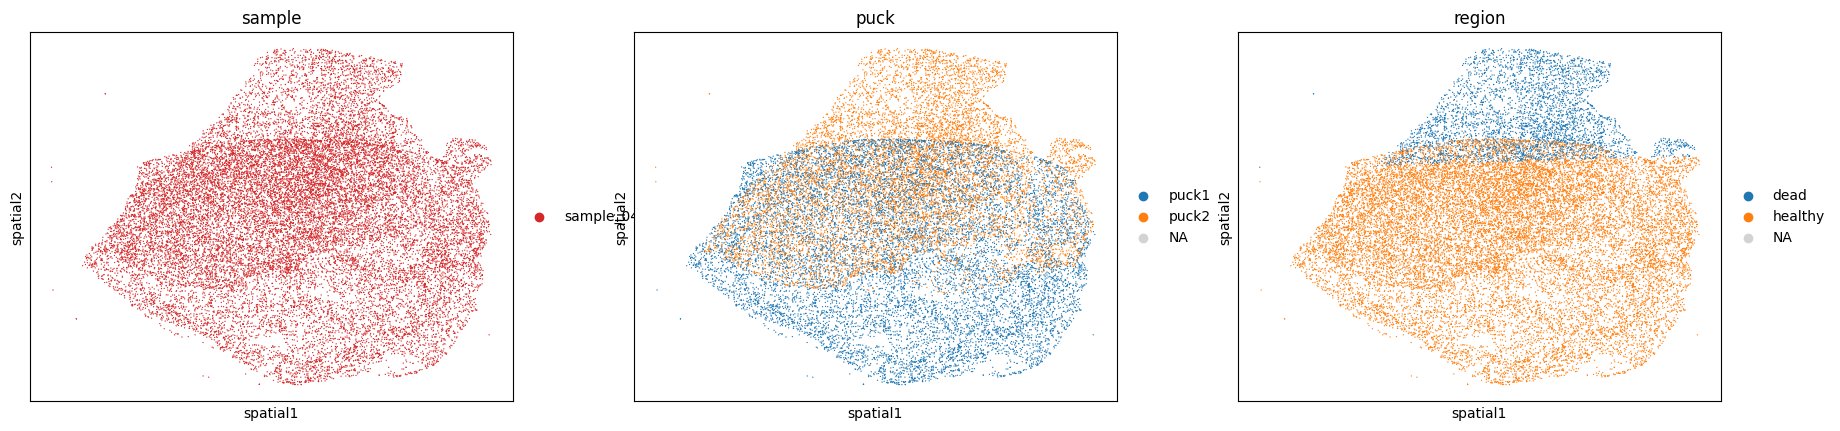

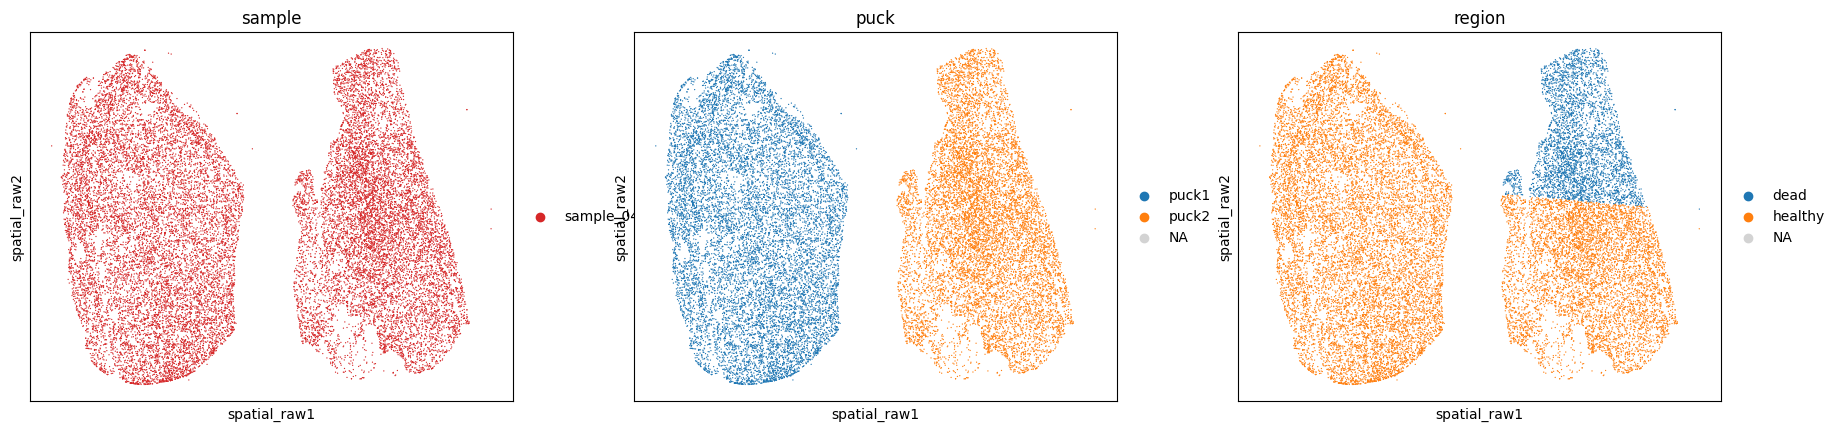

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


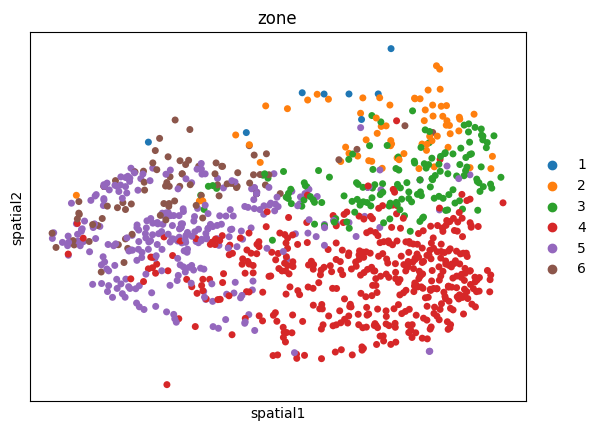

In [38]:
a_sub = adata[adata.obs["sample"] == "sample_04"]
sc.pl.embedding(a_sub, basis="spatial", color=["sample", "puck", "region"])
sc.pl.embedding(a_sub, basis="spatial_raw", color=["sample", "puck", "region"])

a_sub_m1 = a_sub[a_sub.obs["ct_for_deg"] == "Matrix_D1"]
sc.pl.embedding(a_sub_m1, basis="spatial", color=["zone"])

# Plots

In [ ]:
%matplotlib inline

OUT_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad"

adata =  sc.read_h5ad(OUT_PATH, backed="r")

In [39]:
adata_spatial = adata[
    adata.obs["puck"].notna() &
    adata.obs["has_spatial"] 
].to_memory().copy()

adata_spatial.obs["image"] = (
    adata_spatial.obs["sample"].astype(str) + "---" +
    adata_spatial.obs["puck"].astype(str)
)

adata_spatial.obs.image.unique()

coords = adata_spatial.obsm["spatial_aligned"]


In [40]:
palette = json.loads(os.getenv("PALETTE"))


### Plot cell type with zone

/tmp/ipykernel_2882128/560726740.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['3', '4', '4', '4', '4', ..., '3', '4', '5', '4', '4']
Length: 945
Categories (6, object): ['1' < '2' < '3' < '4' < '5' < '6']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  a_img.obs.loc[mask, "zone_label"] = a_img.obs.loc[mask, ZONE_COL]
/tmp/ipykernel_2882128/560726740.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['5', '4', '4', '4', '4', ..., '4', '4', '4', '5', '6']
Length: 1432
Categories (6, object): ['1' < '2' < '3' < '4' < '5' < '6']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  a_img.obs.loc[mask, "zone_label"] = a_img.obs.loc[mask, ZONE_COL]


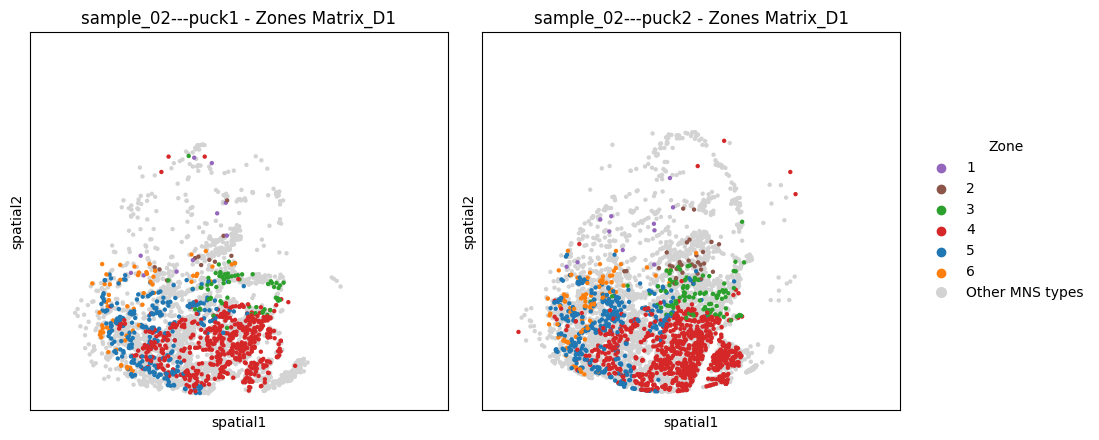

In [41]:
import math
import json
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scanpy as sc

# ---- Configuration ----
ZONE_COL     = "zone"            
CT_COL       = "ct_for_deg"      
CT_VALUES    = ["Matrix_D1"]     
BG_CT_VALUES = ["eMSN_D1D2", "eMSN_NUDAP", "eMSN_StrioMat", "Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2", "non_MSN"]     
SAMPLE_COL   = "sample"          
IMAGE_COL    = "image"           
SAMPLES      = ["sample_02"]     
S            = 40                # Controls BOTH foreground and background dot size
BG_COLOR     = "lightgray"       
N_COLS       = 2
# -----------------------

palette = json.loads(os.getenv("PALETTE"))

# Filter by sample if provided
if SAMPLES is not None:
    adata_work = adata_spatial[adata_spatial.obs[SAMPLE_COL].isin(SAMPLES)].copy()
else:
    adata_work = adata_spatial

images = list(adata_work.obs[IMAGE_COL].unique())
n_img = len(images)
n_rows = math.ceil(n_img / N_COLS)

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(5 * N_COLS, 4.5 * n_rows), squeeze=False)
axes = axes.flatten()

# Dictionary to hold our global legend items
seen_legend_items = {}

for i, img in enumerate(images):

    ax = axes[i]
    a_img = adata_work[adata_work.obs[IMAGE_COL] == img]

    a_img = a_img[a_img.obs[CT_COL].isin(CT_VALUES + BG_CT_VALUES)].copy()  # Keep only relevant cell types

    # create zone labesl ad hoc
    a_img.obs["zone_label"] = np.nan #"Other MSN types"
    mask = a_img.obs[CT_COL].isin(CT_VALUES)
    a_img.obs.loc[mask, "zone_label"] = a_img.obs.loc[mask, ZONE_COL]
    palette["Other MSN types"] = BG_COLOR  # Ensure the "Other" category is colored as background

    sc.pl.embedding(a_img, basis="spatial", color="zone_label", size=S,
                    title=f"{img} - Zones {', '.join(CT_VALUES)}", show=False, ax=ax,
                    palette=palette, edgecolor="none", linewidths=0, na_in_legend=False)
        
    # Grab the legend handles immediately and delete the local legend
    leg = ax.get_legend()
    if leg is not None:
        for handle, text in zip(leg.legend_handles, leg.get_texts()):
            seen_legend_items[text.get_text()] = handle
        leg.remove()
    else:
        ax.set_title(f"{img} - Zones {CT_VALUES}")

    # 3. Standardize Axis Limits (Ensures the view includes all background cells)
    x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
    y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
    x_pad = (x_max - x_min) * 0.02
    y_pad = (y_max - y_min) * 0.02

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    y0, y1 = ax.get_ylim() # Preserve Scanpy's native Y-axis orientation
    lo, hi = y_min - y_pad, y_max + y_pad
    ax.set_ylim((lo, hi) if y0 <= y1 else (hi, lo))

# Hide leftover empty subplots
for j in range(n_img, len(axes)):
    axes[j].axis("off")

# Build the final global legend
handles = list(seen_legend_items.values())
labels  = list(seen_legend_items.keys())

# Add the "Other cell types" entry to the global legend
handles.append(Line2D([0], [0], marker="o", linestyle="",
                      markerfacecolor=BG_COLOR, markeredgecolor="none",
                      markersize=8))
labels.append("Other MNS types")

# Place legend in the empty space on the right (anchored perfectly to the 0.92 cutoff)
fig.legend(handles, labels,
           loc="center left", bbox_to_anchor=(0.92, 0.5),
           title="Zone", frameon=False)

# Confine plots to the left 92% of the figure so the legend has room to breathe
plt.tight_layout(rect=[0, 0, 0.92, 1])
for coll in ax.collections:
    coll.set_rasterized(False)
plt.savefig("/home/gdallagl/myworkdir/XDP/data/_old/images/zone_plots_SlideTag.pdf", bbox_inches="tight")
plt.show()

### Plot Hight mito

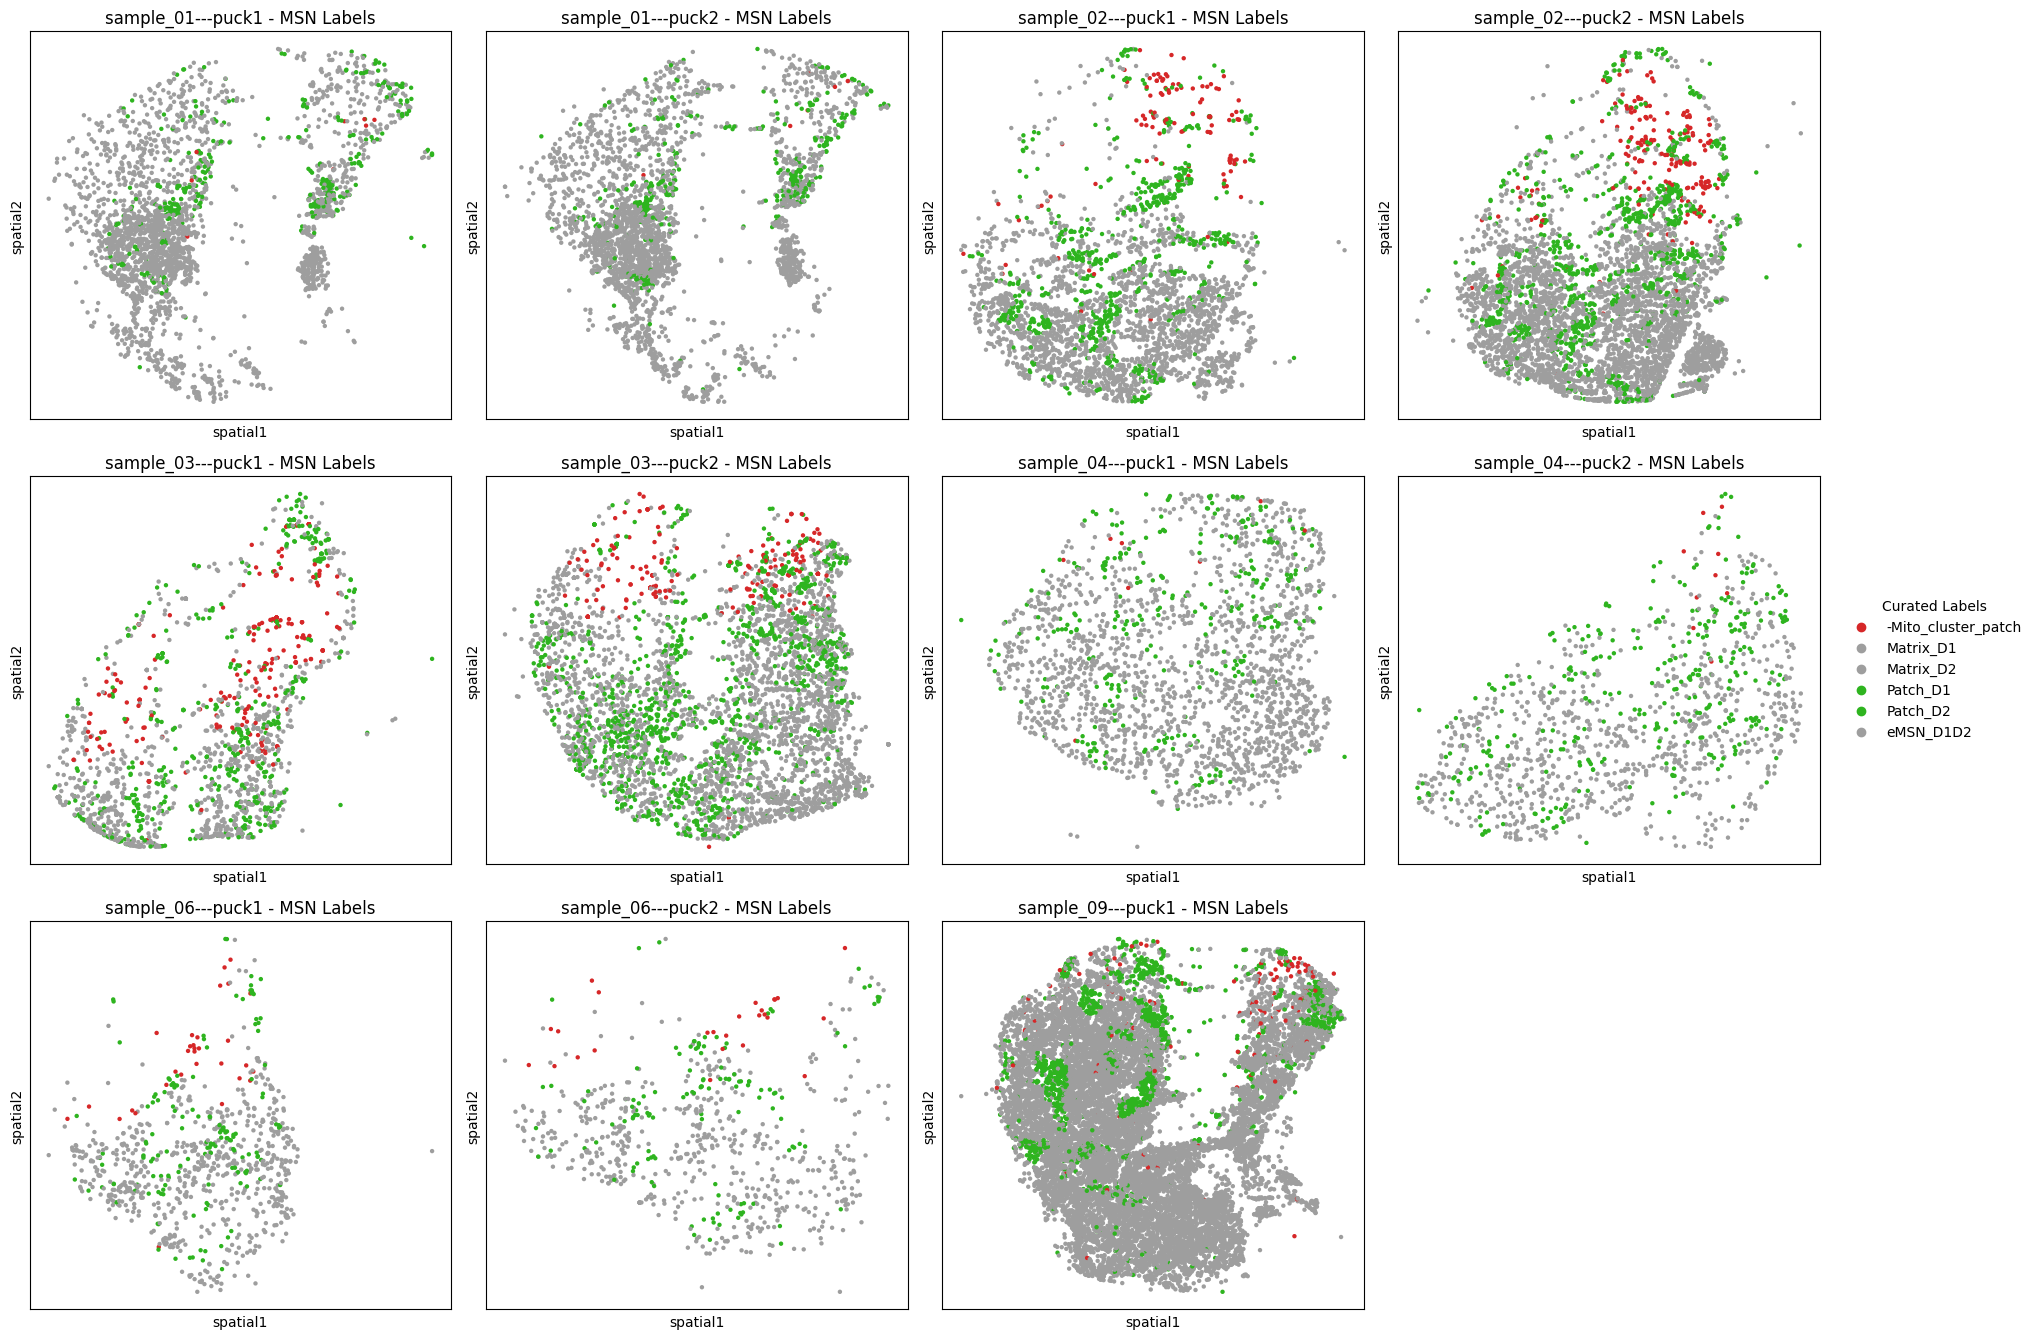

In [42]:
import math
import matplotlib.pyplot as plt
import scanpy as sc

# ---- configure here ----
CT_COL      = "ct_for_deg"          # column to filter & color on
STR_ct      = ["-Mito_cluster_patch", "Patch_D1", "Patch_D2",
               "Matrix_D1", "Matrix_D2", "eMSN_D1D2"]
SAMPLE_COL  = "sample"              # column used to pick samples
IMAGE_COL   = "image"               # one panel per unique value here (sample---puck)
SAMPLES     = ["sample_01", "sample_02", "sample_03", "sample_04", "sample_06", "sample_09"]   # None = all samples
#SAMPLES     = ["sample_05", "sample_07"]   # None = all samples
S           = 40
# ------------------------

palette_map = {
    "-Mito_cluster_patch": "#d62728",
    "Patch_D1":            "#2eb41f",
    "Patch_D2":            "#2eb41f",
    "Matrix_D1":           "#9e9e9e",
    "Matrix_D2":           "#9e9e9e",
    "eMSN_D1D2":           "#9e9e9e",
}

# pick samples first, then enumerate the pucks within them
if SAMPLES is not None:
    a_in = adata_spatial[adata_spatial.obs[SAMPLE_COL].isin(SAMPLES)].copy()
else:
    a_in = adata_spatial

images = list(a_in.obs[IMAGE_COL].unique())
n_img = len(images)
ncols = 4 #min(4, n_img)
nrows = math.ceil(n_img / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
axes = axes.flatten()

for i, img in enumerate(images):
    a_sub = a_in[a_in.obs[IMAGE_COL] == img].copy()
    a_sub_msn = a_sub[a_sub.obs[CT_COL].isin(STR_ct)].copy()
    if hasattr(a_sub_msn.obs[CT_COL], "cat"):
        a_sub_msn.obs[CT_COL] = a_sub_msn.obs[CT_COL].cat.remove_unused_categories()
    a_sub_msn.uns.pop(f"{CT_COL}_colors", None)

    sc.pl.embedding(a_sub_msn, basis="spatial", color=CT_COL, size=S,
                    title=f"{img} - MSN Labels", show=False, ax=axes[i],
                    palette=palette_map)

# Collect unique (label, handle) pairs across all axes, then strip the per-axis legends
seen = {}
for ax in axes[:n_img]:
    leg = ax.get_legend()
    if leg is None:
        continue
    for handle, text in zip(leg.legend_handles, leg.get_texts()):
        seen.setdefault(text.get_text(), handle)
    leg.remove()

# Hide leftover empty axes
for j in range(n_img, len(axes)):
    axes[j].axis("off")

fig.legend(list(seen.values()), list(seen.keys()),
           loc="center left", bbox_to_anchor=(0.92, 0.5),
           title="Curated Labels", frameon=False)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

### Plot D1D2

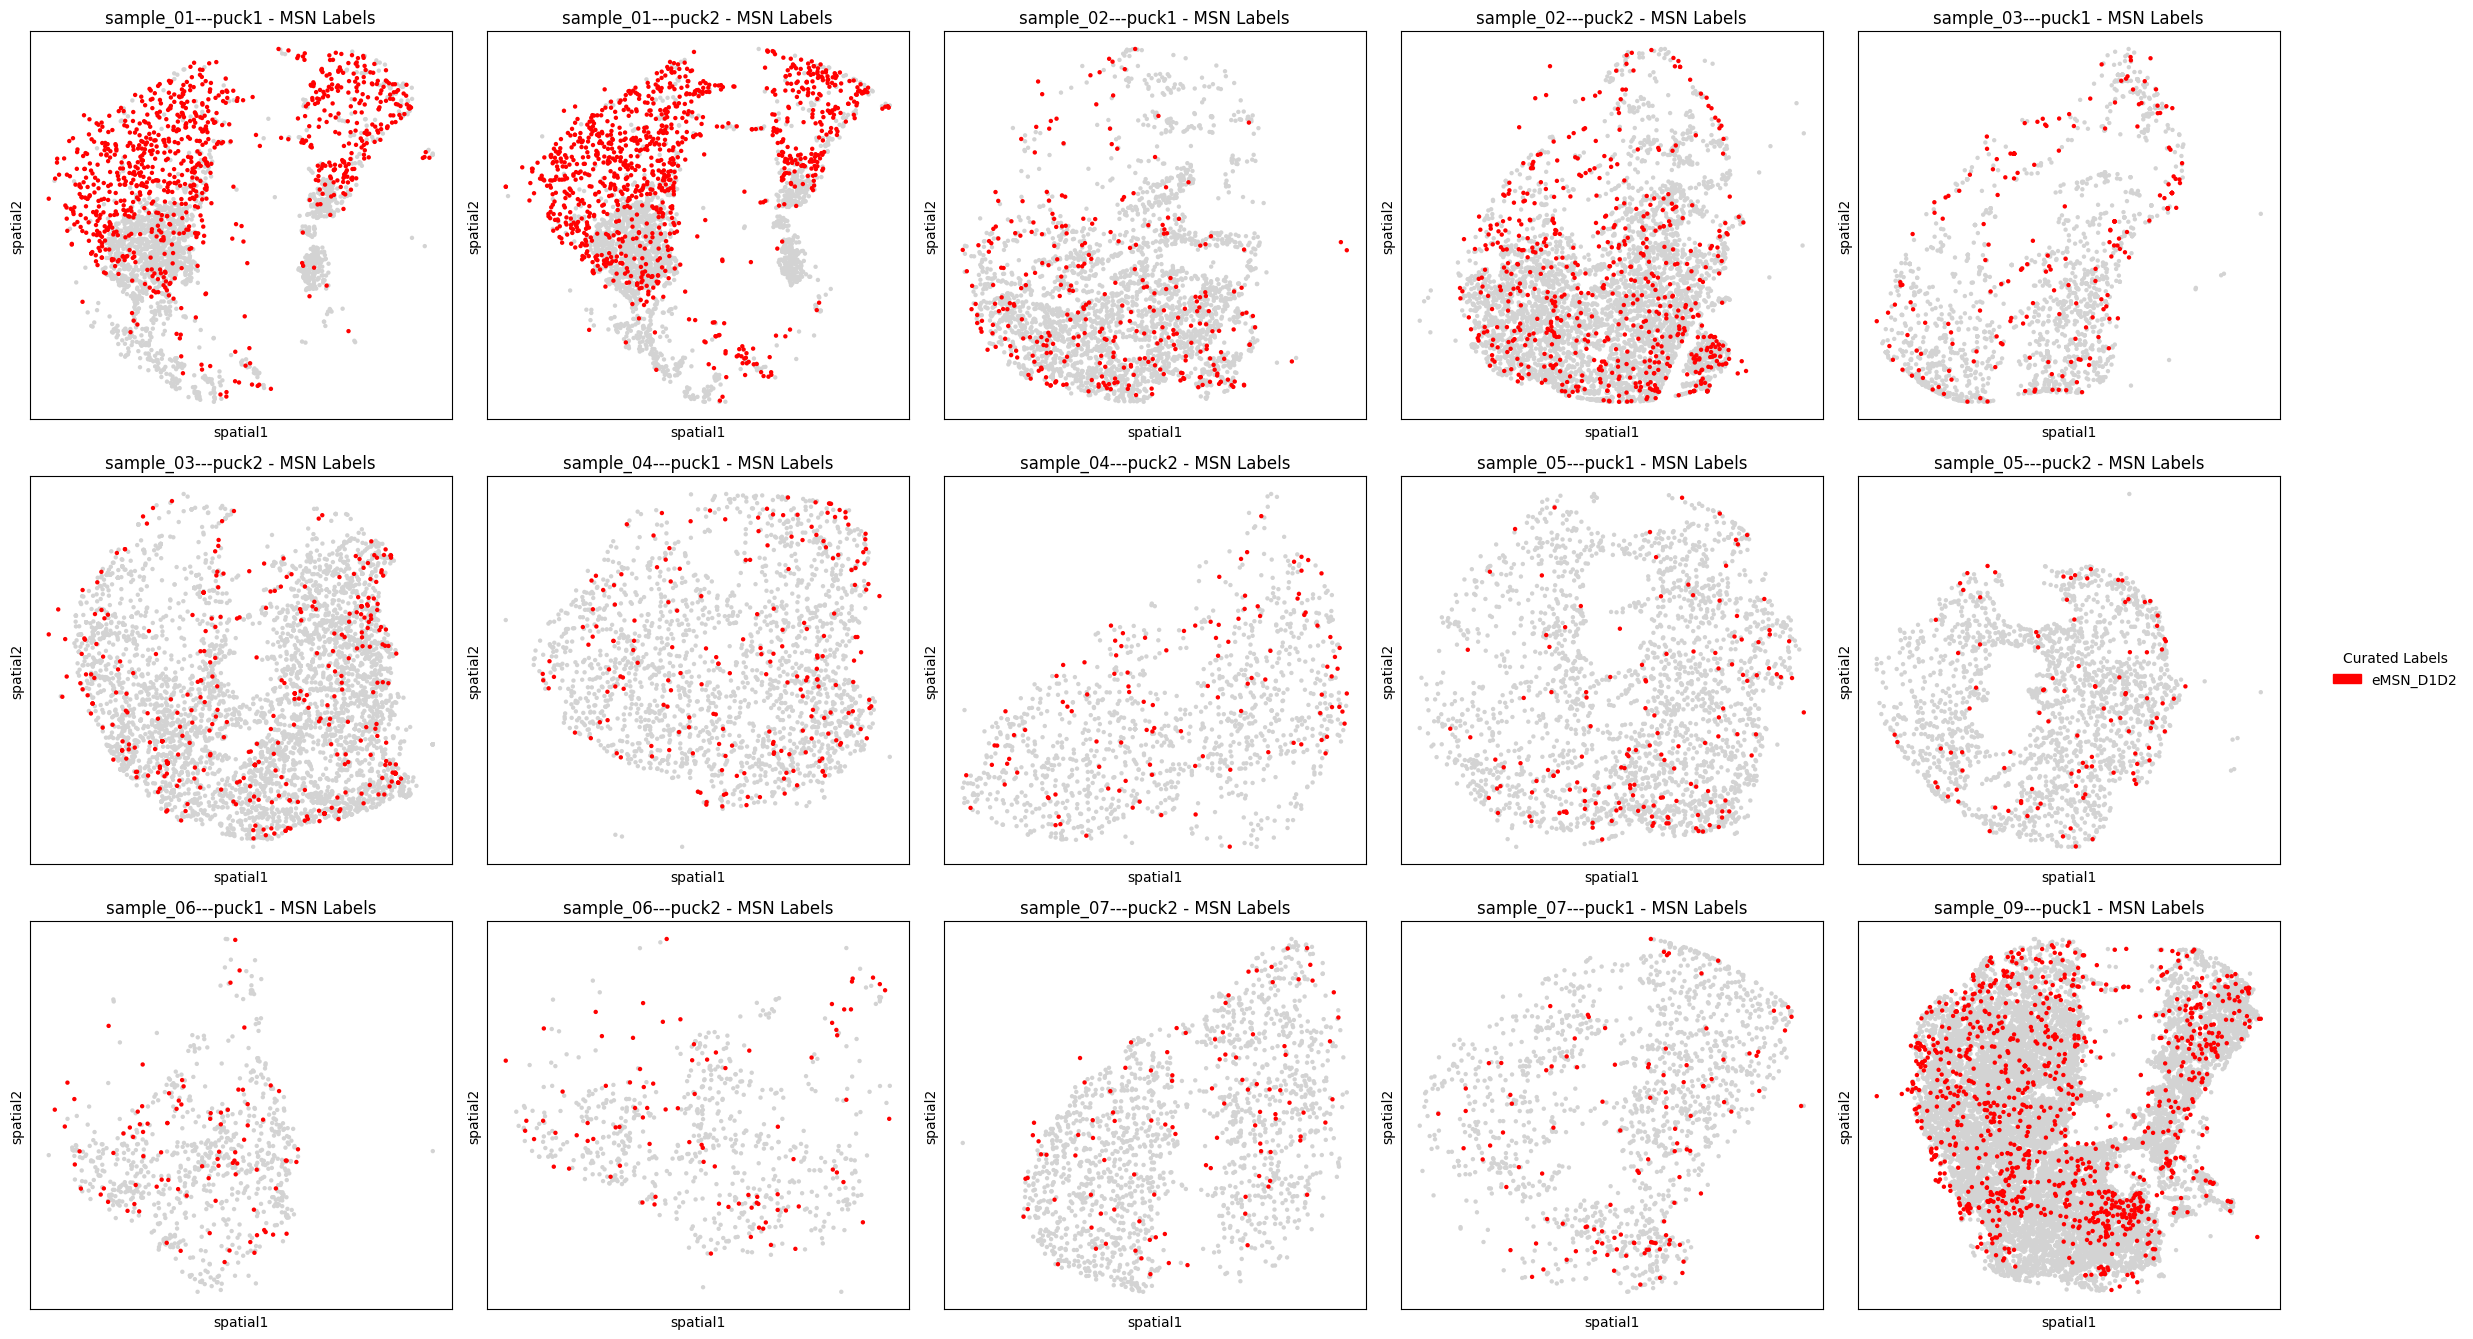

In [43]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

S = 40
CT_COL = "ct_for_deg"
STR_ct = ["-Mito_cluster_patch", "Patch_D1", "Patch_D2", "Matrix_D1", "Matrix_D2", "eMSN_D1D2"]

images = adata_spatial.obs["image"].unique()
ncols = 5
nrows = math.ceil(len(images) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
axes = axes.flatten()

for ax, img in zip(axes, images):
    sub = adata_spatial[
        (adata_spatial.obs["image"] == img) & adata_spatial.obs[CT_COL].isin(STR_ct)
    ].copy()
    sub.obs[CT_COL] = sub.obs[CT_COL].cat.remove_unused_categories()

    palette = {
        ct: "red" if ct == "eMSN_D1D2" else "lightgray"
        for ct in sub.obs[CT_COL].cat.categories
    }

    sc.pl.embedding(
        sub, basis="spatial", color=CT_COL, size=S, ax=ax, show=False,
        title=f"{img} - MSN Labels",
        groups=["eMSN_D1D2"], palette=palette, na_color="lightgray", legend_loc=None,
    )

# Hide leftover empty axes
for ax in axes[len(images):]:
    ax.axis("off")

fig.legend(
    handles=[Patch(color="red", label="eMSN_D1D2")],
    loc="center right", bbox_to_anchor=(0.99, 0.5),
    title="Curated Labels", frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

### Show postion all cell types

In [ ]:
# chekc if non-msn are spaially segregated

import math
import matplotlib.pyplot as plt
import scanpy as sc

# ---- user knobs ----------------------------------------------------------
CT_COL = "Group_name" #"ct_for_deg"
S = 40
NCOLS = 5
HIGHLIGHT = "#d62728"   # red
BACKGROUND = "#dddddd"  # light grey for the other cells

# pick which cell types to plot (one figure each). Set to None to use all.
cell_types_to_plot = [
    'AMY-SLEA-BNST GABA',
    'STRv D1 MSN',
    'ZI-HTH GABA',
    'STRv D2 MSN',
    'STR FS PTHLH-PVALB GABA',
    'STR LYPD6-RSPO2 GABA',
    'STR-BF TAC3-PLPP4-LHX8 GABA',
    'VIP GABA',
    'VTR-HTH Glut',
    'STRd D2 StrioMat Hybrid MSN',
    'OT D1 ICj',
    'STRv D1 NUDAP MSN',
    'STR TAC3-PLPP4 GABA',
    'LAMP5-CXCL14 GABA',
    'STRd D1 Striosome MSN',
    'GPe-NDB-SI LHX6-LHX8-GBX1 GABA',
    'STR D1D2 Hybrid MSN',
    'STRd D2 Matrix MSN',
    'STRd Cholinergic GABA',
    'LAMP5-LHX6 GABA',
    'GPe MEIS2-SOX6 GABA',
    'OB FRMD7 GABA',
    'STR SST-CHODL GABA',
    'OB Dopa-GABA',
    'SN-VTR-HTH GATA3-TCF7L2 GABA',
    'STR SST-ADARB2 GABA',
    'STR SST-RSPO2 GABA',
    'STRd D2 Striosome MSN',
    'AMY-SLEA-BNST D1 GABA',
    'BF SKOR1 Glut',
    'GPin-BF Cholinergic GABA',
    'GPe SOX6-CTXND1 GABA',
    'STR Cholinergic GABA',
    'STRd D1 Matrix MSN',
    'GPi Core',
    'SN EBF2 GABA',
]
# --------------------------------------------------------------------------

images = list(adata_spatial.obs["image"].unique())
n_img = len(images)
nrows = math.ceil(n_img / NCOLS)

if cell_types_to_plot is None:
    cell_types_to_plot = list(adata_spatial.obs[CT_COL].cat.categories)

for ct in cell_types_to_plot:
    fig, axes = plt.subplots(
        nrows, NCOLS, figsize=(5 * NCOLS, 4.5 * nrows), squeeze=False
    )
    axes = axes.flatten()

    for i, img in enumerate(images):
        a_sub = adata_spatial[adata_spatial.obs["image"] == img].copy()

        # binary label: this cell type vs everything else
        a_sub.obs["_hl"] = (
            a_sub.obs[CT_COL].astype(str)
            .where(a_sub.obs[CT_COL].astype(str) == ct, "other")
        )
        a_sub.obs["_hl"] = a_sub.obs["_hl"].astype("category")
        # make sure 'other' is drawn first so highlighted points sit on top
        cats = [c for c in ["other", ct] if c in a_sub.obs["_hl"].cat.categories]
        a_sub.obs["_hl"] = a_sub.obs["_hl"].cat.reorder_categories(cats)
        a_sub.uns.pop("_hl_colors", None)

        palette = {"other": BACKGROUND, ct: HIGHLIGHT}

        sc.pl.embedding(
            a_sub, basis="spatial", color="_hl", size=S,
            title=img, show=False, ax=axes[i], palette=palette, legend_loc=None,
        )

    for j in range(n_img, len(axes)):
        axes[j].axis("off")

    # one shared legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker="o", linestyle="", color=HIGHLIGHT, label=ct),
        Line2D([0], [0], marker="o", linestyle="", color=BACKGROUND, label="other"),
    ]
    fig.legend(
        handles=handles, loc="center right",
        bbox_to_anchor=(0.99, 0.5), frameon=False, title="Cell type",
    )

    fig.suptitle(f"Highlight: {ct}", fontsize=14, y=1.00)
    plt.tight_layout(rect=[0, 0, 0.92, 0.98])
    plt.show()